
# Longitudinal Permutation Entropy — Drivers A–F across Stints 1–5 (v5)

This notebook is an updated version of **`entropy_JSD_PE_Pipeline_v4`** focused on the
Permutation Entropy (PE) story required for Sections **6.2** and **6.4** of the manuscript.

The data-reading pipeline is preserved:

`resolve_stint_files → load_stint → basic_clean_and_units → build_lap_validity_table → assign_sectors`

The analytical design is changed from **“select the best stint”** to **“retain Stints 1–5”**.

### Primary comparisons

1. **Driver B (Intermediate) vs Driver A (Expert)**, matched by track and stint.
2. **Drivers C, D, E and F (Beginners)**, each compared with **Driver B**.
3. Beginner-group summaries are calculated **after** the individual comparisons using the
   driver-level median and interquartile range. Beginner observations are not pooled as if
   they were independent samples.

### Sign convention

\[
\Delta PE = PE_{\mathrm{test}} - PE_{\mathrm{reference}}
\]

Positive values indicate greater **ordinal complexity** in the test driver. They must not be
interpreted automatically as worse driving; their meaning depends on channel, sector, and
their association with time loss.



## What this version adds

The original notebook already computes normalized PE by sector, but it selects one stint per
driver. That prevents the manuscript from telling a longitudinal story across the five
stints. This version adds:

- PE trajectories across Stints 1–5 for all six drivers;
- Driver B vs Driver A reference-distance trajectories;
- each beginner vs Driver B and a separate beginner-group median;
- sector × stint \(\Delta PE\) heatmaps with one common diverging scale;
- an amateur consensus marker instead of hiding C–F heterogeneity through raw pooling;
- PE–lap-time phase trajectories;
- sector-level PE/time-loss association maps across stints;
- CSV, LaTeX, PDF, and PNG exports.

The figures use Gestalt principles deliberately: consistent encoding by proficiency group
(**similarity**), aligned small multiples (**proximity**), connected stint trajectories
(**continuity/common fate**), shared scales (**good comparison**), and restrained color so
that the reference contrast remains the visual foreground (**figure–ground**).


In [2]:

# 0. Imports and project configuration
import os
import re
import sys
import math
import warnings
from pathlib import Path
from typing import Dict, Iterable, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr
from statsmodels.stats.multitest import multipletests

try:
    import antropy as ant
except ImportError as exc:
    raise ImportError(
        "This notebook requires antropy. Install it with: pip install antropy"
    ) from exc


def find_project_root(start: Optional[Path] = None) -> Path:
    """Locate the closest folder containing config.py."""
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "config.py").exists():
            return candidate
        if (candidate / "Iracing" / "config.py").exists():
            return candidate / "Iracing"
    # Preserve the original notebook convention as the final fallback.
    return Path("..").resolve()


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    get_ipython().run_line_magic("load_ext", "autoreload")
    get_ipython().run_line_magic("autoreload", "2")
except Exception:
    pass

from config import (
    TRACK_CONFIGS,
    DATASETS,
    DRIVER_ALIAS,
    resolve_stint_files,
    load_stint,
    basic_clean_and_units,
    build_lap_validity_table,
    assign_sectors,
)

load_from_ibt = load_stint

print(f"Project root : {PROJECT_ROOT}")
print(f"Tracks       : {list(TRACK_CONFIGS.keys())}")
print(f"Aliases      : {DRIVER_ALIAS}")
print(f"antropy      : {getattr(ant, '__version__', 'available')}")


Project root : C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing
Tracks       : ['charlotte_roval_2025', 'summit_point']
Aliases      : {'Rodrigo': 'Driver A', 'Tomaz': 'Driver B', 'Morsinaldo': 'Driver C', 'Thallys': 'Driver D', 'Igor': 'Driver E', 'Hilton': 'Driver F'}
antropy      : 0.2.2


In [3]:

# 1. Study design and reproducible analysis parameters

DRIVER_TIER = {
    "Rodrigo":    {"alias": DRIVER_ALIAS.get("Rodrigo", "Driver A"), "tier": "Expert"},
    "Tomaz":      {"alias": DRIVER_ALIAS.get("Tomaz", "Driver B"), "tier": "Intermediate"},
    "Morsinaldo": {"alias": DRIVER_ALIAS.get("Morsinaldo", "Driver C"), "tier": "Beginner"},
    "Thallys":    {"alias": DRIVER_ALIAS.get("Thallys", "Driver D"), "tier": "Beginner"},
    "Igor":       {"alias": DRIVER_ALIAS.get("Igor", "Driver E"), "tier": "Beginner"},
    "Hilton":     {"alias": DRIVER_ALIAS.get("Hilton", "Driver F"), "tier": "Beginner"},
}

DRIVER_ORDER = ["Rodrigo", "Tomaz", "Morsinaldo", "Thallys", "Igor", "Hilton"]
BEGINNER_DRIVERS = ["Morsinaldo", "Thallys", "Igor", "Hilton"]
STINT_NUMBERS = [1, 2, 3, 4, 5]

COMPARISONS = [
    {"id": "B_vs_A", "ref": "Rodrigo", "test": "Tomaz", "group": "Intermediate vs Expert"},
    {"id": "C_vs_B", "ref": "Tomaz", "test": "Morsinaldo", "group": "Beginner vs Intermediate"},
    {"id": "D_vs_B", "ref": "Tomaz", "test": "Thallys", "group": "Beginner vs Intermediate"},
    {"id": "E_vs_B", "ref": "Tomaz", "test": "Igor", "group": "Beginner vs Intermediate"},
    {"id": "F_vs_B", "ref": "Tomaz", "test": "Hilton", "group": "Beginner vs Intermediate"},
]

REQUESTED_TRACKS = ["charlotte_roval_2025", "summit_point"]
BATCH_TRACKS = [
    track_id for track_id in REQUESTED_TRACKS
    if track_id in TRACK_CONFIGS and track_id in DATASETS
]

VARIABLES_PE = [
    ("Brake_Pct", "Brake (%)"),
    ("TotalAccel_G", "Combined G-Force"),
    ("SteeringWheelAngle", "Steering Angle (deg)"),
    ("Throttle_Pct", "Throttle (%)"),
]
VAR_LABELS = [label for _, label in VARIABLES_PE]

PE_ORDER = 3
PE_DELAY = 1
PE_MIN_PATTERNS = 30
MIN_VALID_LAPS_STINT = 2
TIME_PROFILE_MODE = "best"  # "best" preserves the manuscript's performance-gap protocol.
FDR_ALPHA = 0.05
RANDOM_SEED = 2026

# Use this only when the keys in DATASETS cannot be parsed automatically.
# Example: {("charlotte_roval_2025", "Rodrigo", 1): "session_alpha"}
STINT_NAME_OVERRIDES = {}

if PROJECT_ROOT.name.lower() == "iracing":
    default_img_root = PROJECT_ROOT / "img"
else:
    default_img_root = PROJECT_ROOT / "Iracing" / "img"

OUTPUT_ROOT = Path(
    os.environ.get(
        "IRACING_PE_OUTPUT_DIR",
        str(default_img_root / "permutation_entropy_stints_1_5_v5"),
    )
)
FIG_DIR = OUTPUT_ROOT / "figures"
TABLE_DIR = OUTPUT_ROOT / "tables"
for folder in (FIG_DIR, TABLE_DIR):
    folder.mkdir(parents=True, exist_ok=True)

print(f"Tracks used  : {BATCH_TRACKS}")
print(f"Stints       : {STINT_NUMBERS}")
print(f"PE           : m={PE_ORDER}, tau={PE_DELAY}, normalized=True")
print(f"Output root  : {OUTPUT_ROOT}")


Tracks used  : ['charlotte_roval_2025', 'summit_point']
Stints       : [1, 2, 3, 4, 5]
PE           : m=3, tau=1, normalized=True
Output root  : C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\permutation_entropy_stints_1_5_v5



## 2. Discover and load Stints 1–5

The original notebook selected the non-warm-up stint with the largest number of valid laps.
The functions below instead resolve a deterministic mapping from the session keys in
`DATASETS` to Stints 1–5. A manual override dictionary remains available only for unusual
session names.

The audit table is part of the analysis: missing stints, fewer than two valid laps, or failed
loads remain visible instead of being silently dropped.


In [4]:

# 2.1 Stint discovery

import unicodedata


def _normalize_text(value: str) -> str:
    value = unicodedata.normalize("NFKD", str(value))
    value = "".join(ch for ch in value if not unicodedata.combining(ch))
    return value.lower().strip()


def _is_warmup(stint_name: str) -> bool:
    text = _normalize_text(stint_name)
    return (
        text.startswith("warmup")
        or "warm up" in text
        or "aquec" in text
        or "practice" in text
        or "treino livre" in text
    )


def _natural_key(value: str):
    return [
        int(token) if token.isdigit() else token
        for token in re.split(r"(\d+)", _normalize_text(value))
    ]


def parse_stint_number(stint_name: str) -> Optional[int]:
    """Parse Stint 1..5 from common session-key conventions."""
    text = _normalize_text(stint_name)

    patterns = [
        r"(?:stint|session|sessao|run|bateria|heat)[\s_\-]*0?([1-5])(?:\D|$)",
        r"^0?([1-5])(?:\D|$)",
        r"(?:^|\D)s[\s_\-]*0?([1-5])(?:\D|$)",
    ]
    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return int(match.group(1))
    return None


def discover_driver_stints(track_id: str, driver: str) -> Tuple[Dict[int, str], Dict[int, str]]:
    """
    Return {stint_number: DATASETS session key} and the discovery method for each stint.
    Explicit overrides take priority. Unmatched non-warm-up keys are assigned only to
    remaining stint numbers and are reported as an ordered fallback.
    """
    sessions = DATASETS[track_id]["sessions"].get(driver, {})
    available_keys = [key for key in sessions if not _is_warmup(key)]

    mapping: Dict[int, str] = {}
    method: Dict[int, str] = {}

    for stint_no in STINT_NUMBERS:
        override = STINT_NAME_OVERRIDES.get((track_id, driver, stint_no))
        if override is not None:
            if override not in sessions:
                raise KeyError(
                    f"Override {override!r} was not found for {track_id}/{driver}."
                )
            mapping[stint_no] = override
            method[stint_no] = "manual override"

    for key in sorted(available_keys, key=_natural_key):
        parsed = parse_stint_number(key)
        if parsed in STINT_NUMBERS and parsed not in mapping:
            mapping[parsed] = key
            method[parsed] = "parsed from session key"

    unmatched = [
        key for key in sorted(available_keys, key=_natural_key)
        if key not in mapping.values()
    ]
    missing_numbers = [number for number in STINT_NUMBERS if number not in mapping]

    for stint_no, key in zip(missing_numbers, unmatched):
        mapping[stint_no] = key
        method[stint_no] = "ordered fallback"

    return mapping, method


discovery_rows = []
for track_id in BATCH_TRACKS:
    for driver in DRIVER_ORDER:
        if driver not in DATASETS[track_id]["sessions"]:
            continue
        mapping, method = discover_driver_stints(track_id, driver)
        for stint_no in STINT_NUMBERS:
            discovery_rows.append(
                {
                    "Track": track_id,
                    "Driver": driver,
                    "Alias": DRIVER_TIER[driver]["alias"],
                    "Stint": stint_no,
                    "SessionKey": mapping.get(stint_no),
                    "DiscoveryMethod": method.get(stint_no, "missing"),
                }
            )

STINT_DISCOVERY = pd.DataFrame(discovery_rows)
display(STINT_DISCOVERY)


,Track,Driver,Alias,Stint,SessionKey,DiscoveryMethod
0,charlotte_roval_2025,Rodrigo,Driver A,1,stint_1,parsed from session key
1,charlotte_roval_2025,Rodrigo,Driver A,2,None,missing
2,charlotte_roval_2025,Rodrigo,Driver A,3,None,missing
3,charlotte_roval_2025,Rodrigo,Driver A,4,None,missing
4,charlotte_roval_2025,Rodrigo,Driver A,5,None,missing
5,charlotte_roval_2025,Tomaz,Driver B,1,stint_1,parsed from session key
6,charlotte_roval_2025,Tomaz,Driver B,2,stint_2,parsed from session key
7,charlotte_roval_2025,Tomaz,Driver B,3,stint_3,parsed from session key
8,charlotte_roval_2025,Tomaz,Driver B,4,stint_4,parsed from session key
9,charlotte_roval_2025,Tomaz,Driver B,5,stint_5,parsed from session key


In [5]:

# 2.2 Shared preprocessing and longitudinal loading

def preprocess_ibt_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Add local lap time and total acceleration magnitude."""
    df = df.copy()
    df.sort_values(["Lap", "SessionTime"], inplace=True)
    df["LocalLapTime"] = df.groupby("Lap")["SessionTime"].transform(
        lambda values: values - values.min()
    )

    if "TotalAccel_G" not in df.columns:
        lat_g = df.get("LatAccel", pd.Series(0.0, index=df.index)) / 9.81
        lon_g = df.get("LongAccel", pd.Series(0.0, index=df.index)) / 9.81
        df["TotalAccel_G"] = np.sqrt(lat_g ** 2 + lon_g ** 2)

    return df


def load_one_stint(
    track_id: str,
    driver: str,
    stint_no: int,
    session_key: Optional[str],
) -> Tuple[Optional[dict], dict]:
    """Load and validate one driver/track/stint record."""
    audit = {
        "Track": track_id,
        "TrackName": TRACK_CONFIGS[track_id]["track_name"],
        "Driver": driver,
        "Alias": DRIVER_TIER[driver]["alias"],
        "Tier": DRIVER_TIER[driver]["tier"],
        "Stint": stint_no,
        "SessionKey": session_key,
        "NValidLaps": 0,
        "NSamples": 0,
        "BestLap_s": np.nan,
        "Status": "missing session key",
        "Message": "",
    }

    if not session_key:
        return None, audit

    try:
        file_paths = [
            str(path)
            for path in resolve_stint_files(track_id, driver, session_key)
        ]
        df_raw = load_from_ibt(file_paths)

        if df_raw is None or df_raw.empty:
            audit["Status"] = "empty"
            return None, audit

        df_clean = basic_clean_and_units(df_raw)
        validity = build_lap_validity_table(
            df_clean,
            manual_invalid=set(),
            verbose=False,
        )

        valid_laps = validity.loc[validity["Valid"], "Lap"].tolist()
        n_valid = len(valid_laps)
        audit["NValidLaps"] = n_valid

        if "LapTime_s" in validity.columns and n_valid:
            audit["BestLap_s"] = float(
                validity.loc[validity["Valid"], "LapTime_s"].min()
            )

        if n_valid < MIN_VALID_LAPS_STINT:
            audit["Status"] = "insufficient valid laps"
            audit["Message"] = (
                f"Requires >= {MIN_VALID_LAPS_STINT}; found {n_valid}."
            )
            return None, audit

        df_valid = df_clean[df_clean["Lap"].isin(valid_laps)].copy()
        df_valid = preprocess_ibt_dataframe(df_valid)

        audit["NSamples"] = int(len(df_valid))
        audit["Status"] = "ok"

        record = {
            "track_id": track_id,
            "driver": driver,
            "stint": stint_no,
            "session_key": session_key,
            "df": df_valid,
            "validity": validity,
            "valid_laps": valid_laps,
            "n_valid": n_valid,
            "best_lap_s": audit["BestLap_s"],
        }
        return record, audit

    except Exception as exc:
        audit["Status"] = "error"
        audit["Message"] = f"{type(exc).__name__}: {exc}"
        return None, audit


LONG_DATA: Dict[str, Dict[str, Dict[int, dict]]] = {
    track_id: {} for track_id in BATCH_TRACKS
}
audit_rows = []

for track_id in BATCH_TRACKS:
    print(f"\n=== Loading {TRACK_CONFIGS[track_id]['track_name']} ===")
    for driver in DRIVER_ORDER:
        if driver not in DATASETS[track_id]["sessions"]:
            continue

        stint_map, _ = discover_driver_stints(track_id, driver)
        LONG_DATA[track_id][driver] = {}

        for stint_no in STINT_NUMBERS:
            record, audit = load_one_stint(
                track_id=track_id,
                driver=driver,
                stint_no=stint_no,
                session_key=stint_map.get(stint_no),
            )
            audit_rows.append(audit)

            if record is not None:
                LONG_DATA[track_id][driver][stint_no] = record
                print(
                    f"{DRIVER_TIER[driver]['alias']:<9} "
                    f"Stint {stint_no}: {record['n_valid']} valid laps"
                )
            else:
                print(
                    f"{DRIVER_TIER[driver]['alias']:<9} "
                    f"Stint {stint_no}: {audit['Status']}"
                )

DATA_AUDIT = pd.DataFrame(audit_rows).sort_values(
    ["Track", "Alias", "Stint"]
).reset_index(drop=True)

DATA_AUDIT.to_csv(TABLE_DIR / "data_audit_stints_1_5.csv", index=False)
display(DATA_AUDIT)



=== Loading Charlotte Roval 2025 ===
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-02-08 15-06-22(Rodrigo).ibt … OK (274,948 samples, laps 0–49)
Driver A  Stint 1: 36 valid laps
Driver A  Stint 2: missing session key
Driver A  Stint 3: missing session key
Driver A  Stint 4: missing session key
Driver A  Stint 5: missing session key
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-07-20 18-30-08(Tomaz-stint1).ibt … OK (20,065 samples, laps 0–3)
Driver B  Stint 1: 2 valid laps
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-07-20 18-47-14(Tomaz-stint2).ibt … OK (19,078 samples, laps 0–3)
Driver B  Stint 2: 2 valid laps
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-07-20 19-01-52(Tomaz-stint3).ibt … OK (18,636 samples, laps 0–3)
Driver B  Stint 3: 2 valid laps
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-07-20 19-14-44(Tomaz-stint4).ibt … OK (25,801 samples, laps 0–4)
Driver B  Stint 4: 3 valid laps
    [1/1] Loading mx5 m

,Track,TrackName,Driver,Alias,Tier,Stint,SessionKey,NValidLaps,NSamples,BestLap_s,Status,Message
0,charlotte_roval_2025,Charlotte Roval 2025,Rodrigo,Driver A,Expert,1,stint_1,36,210779,95.483333,ok,
1,charlotte_roval_2025,Charlotte Roval 2025,Rodrigo,Driver A,Expert,2,None,0,0,NaN,missing session key,
2,charlotte_roval_2025,Charlotte Roval 2025,Rodrigo,Driver A,Expert,3,None,0,0,NaN,missing session key,
3,charlotte_roval_2025,Charlotte Roval 2025,Rodrigo,Driver A,Expert,4,None,0,0,NaN,missing session key,
4,charlotte_roval_2025,Charlotte Roval 2025,Rodrigo,Driver A,Expert,5,None,0,0,NaN,missing session key,
5,charlotte_roval_2025,Charlotte Roval 2025,Tomaz,Driver B,Intermediate,1,stint_1,2,12148,96.466667,ok,
6,charlotte_roval_2025,Charlotte Roval 2025,Tomaz,Driver B,Intermediate,2,stint_2,2,12211,97.933333,ok,
7,charlotte_roval_2025,Charlotte Roval 2025,Tomaz,Driver B,Intermediate,3,stint_3,2,11695,96.066667,ok,
8,charlotte_roval_2025,Charlotte Roval 2025,Tomaz,Driver B,Intermediate,4,stint_4,3,18329,97.333333,ok,
9,charlotte_roval_2025,Charlotte Roval 2025,Tomaz,Driver B,Intermediate,5,stint_5,2,11631,96.766667,ok,


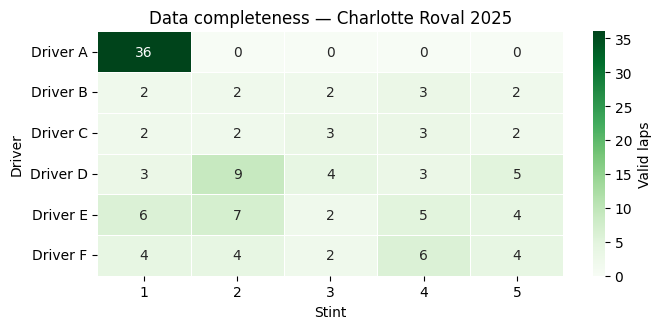

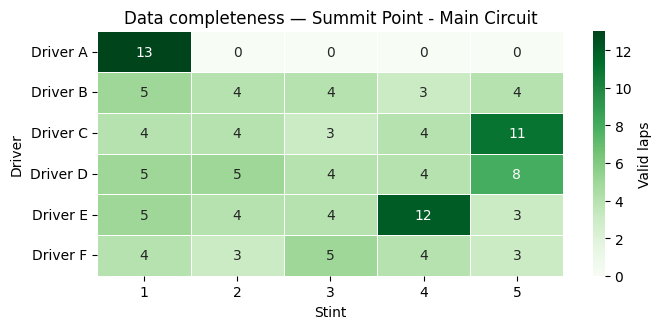

In [6]:

# 2.3 Data-completeness audit figure

def plot_data_completeness(audit_df: pd.DataFrame):
    for track_id in BATCH_TRACKS:
        track_df = audit_df[audit_df["Track"] == track_id].copy()
        if track_df.empty:
            continue

        aliases = [
            DRIVER_TIER[driver]["alias"]
            for driver in DRIVER_ORDER
            if driver in track_df["Driver"].unique()
        ]
        pivot = (
            track_df.pivot(index="Alias", columns="Stint", values="NValidLaps")
            .reindex(index=aliases, columns=STINT_NUMBERS)
        )

        fig, ax = plt.subplots(figsize=(7.0, 3.4))
        sns.heatmap(
            pivot,
            annot=True,
            fmt=".0f",
            cmap="Greens",
            vmin=0,
            cbar_kws={"label": "Valid laps"},
            linewidths=0.6,
            linecolor="white",
            ax=ax,
        )
        ax.set_title(
            f"Data completeness — {TRACK_CONFIGS[track_id]['track_name']}"
        )
        ax.set_xlabel("Stint")
        ax.set_ylabel("Driver")
        fig.tight_layout()
        fig.savefig(
            FIG_DIR / f"QA_data_completeness_{track_id}.pdf",
            bbox_inches="tight",
        )
        fig.savefig(
            FIG_DIR / f"QA_data_completeness_{track_id}.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()


plot_data_completeness(DATA_AUDIT)



## 3. Sector assignment and per-lap Permutation Entropy

PE is computed separately for each valid lap and analytical sector. The stint-level value is
therefore not calculated from one concatenated signal, which would introduce artificial
ordinal patterns at lap boundaries.

For a series of length \(N\), order \(m=3\), and delay \(\tau=1\), the number of available
ordinal patterns is \(N-(m-1)\tau\). Windows with fewer than `PE_MIN_PATTERNS` patterns are
reported as invalid. The notebook also records the adjacent-sample plateau fraction because
brake and throttle signals can contain many repeated values.


In [7]:

# 3.1 Assign analytical sectors to every loaded stint

TRACK_META = {}

for track_id in BATCH_TRACKS:
    cfg = TRACK_CONFIGS[track_id]
    edges = list(cfg["custom_edges"])
    configured_order = list(cfg.get("sector_names", range(1, len(edges))))

    observed_values = []

    for driver, stint_records in LONG_DATA[track_id].items():
        for stint_no, record in stint_records.items():
            df_s = assign_sectors(record["df"].copy(), edges)
            sector_col = "Sector" if "Sector" in df_s.columns else "sector"
            if sector_col not in df_s.columns:
                raise KeyError(
                    f"assign_sectors did not create a Sector/sector column for {track_id}."
                )

            record["df_s"] = df_s
            record["sector_col"] = sector_col
            observed_values.extend(df_s[sector_col].dropna().unique().tolist())

    observed_unique = list(pd.unique(pd.Series(observed_values).dropna()))

    if configured_order and set(configured_order).intersection(observed_unique):
        sector_order = [
            sector for sector in configured_order if sector in observed_unique
        ]
    else:
        try:
            sector_order = sorted(observed_unique)
        except TypeError:
            sector_order = sorted(observed_unique, key=lambda value: str(value))

    if not sector_order:
        sector_order = list(range(1, len(edges)))

    sector_to_index = {
        sector: index + 1 for index, sector in enumerate(sector_order)
    }

    for driver, stint_records in LONG_DATA[track_id].items():
        for stint_no, record in stint_records.items():
            df_s = record["df_s"].copy()
            sector_col = record["sector_col"]
            df_s["SectorRaw"] = df_s[sector_col]
            df_s["SectorIndex"] = df_s["SectorRaw"].map(sector_to_index)
            record["df_s"] = df_s

    TRACK_META[track_id] = {
        "track_name": cfg["track_name"],
        "edges": edges,
        "sector_order": sector_order,
        "sector_to_index": sector_to_index,
        "n_sectors": len(sector_order),
    }

    print(
        f"{cfg['track_name']}: {len(sector_order)} sectors "
        f"({sector_order[:3]} ... {sector_order[-3:]})"
    )


Charlotte Roval 2025: 18 sectors ([1, 2, 3] ... [16, 17, 18])
Summit Point - Main Circuit: 10 sectors ([1, 2, 3] ... [8, 9, 10])


In [8]:

# 3.2 PE estimator and long-format table

def permutation_entropy_record(
    series: Iterable[float],
    order: int = PE_ORDER,
    delay: int = PE_DELAY,
    min_patterns: int = PE_MIN_PATTERNS,
) -> dict:
    values = np.asarray(pd.Series(series).dropna(), dtype=float)
    n_samples = int(values.size)
    n_patterns = n_samples - (order - 1) * delay

    if n_samples > 1:
        scale = max(float(np.nanstd(values)), 1.0)
        plateau_fraction = float(
            np.mean(np.isclose(np.diff(values), 0.0, atol=1e-10 * scale))
        )
    else:
        plateau_fraction = np.nan

    result = {
        "PE_norm": np.nan,
        "NSamples": n_samples,
        "NPatterns": max(n_patterns, 0),
        "PlateauFraction": plateau_fraction,
        "PEValid": False,
    }

    if n_patterns < min_patterns:
        return result

    pe_value = ant.perm_entropy(
        values,
        order=order,
        delay=delay,
        normalize=True,
    )

    result["PE_norm"] = float(pe_value)
    result["PEValid"] = bool(np.isfinite(pe_value))
    return result


def build_pe_long_table() -> pd.DataFrame:
    rows = []

    for track_id in BATCH_TRACKS:
        meta = TRACK_META[track_id]

        for driver in DRIVER_ORDER:
            for stint_no, record in LONG_DATA[track_id].get(driver, {}).items():
                df_s = record["df_s"]

                for lap in sorted(df_s["Lap"].dropna().unique()):
                    lap_df = df_s[df_s["Lap"] == lap]

                    for sector_raw in meta["sector_order"]:
                        sector_df = (
                            lap_df[lap_df["SectorRaw"] == sector_raw]
                            .sort_values("SessionTime")
                        )
                        if sector_df.empty:
                            continue

                        sector_index = meta["sector_to_index"][sector_raw]

                        for variable_col, variable_label in VARIABLES_PE:
                            if variable_col not in sector_df.columns:
                                continue

                            pe_rec = permutation_entropy_record(
                                sector_df[variable_col].values
                            )

                            rows.append(
                                {
                                    "Track": track_id,
                                    "TrackName": meta["track_name"],
                                    "Driver": driver,
                                    "Alias": DRIVER_TIER[driver]["alias"],
                                    "Tier": DRIVER_TIER[driver]["tier"],
                                    "Stint": stint_no,
                                    "Lap": int(lap),
                                    "Sector": sector_raw,
                                    "SectorIndex": sector_index,
                                    "VariableCol": variable_col,
                                    "Variable": variable_label,
                                    **pe_rec,
                                }
                            )

    return pd.DataFrame(rows)


PE_LONG = build_pe_long_table()

if PE_LONG.empty:
    raise RuntimeError(
        "No PE observations were produced. Check the audit table and telemetry columns."
    )

PE_LONG.to_csv(TABLE_DIR / "pe_per_lap_sector_long.csv", index=False)

print(f"PE rows        : {len(PE_LONG):,}")
print(f"Valid PE rows  : {PE_LONG['PEValid'].sum():,}")
print(f"Invalid rows   : {(~PE_LONG['PEValid']).sum():,}")
display(PE_LONG.head())


PE rows        : 14,424
Valid PE rows  : 14,424
Invalid rows   : 0


,Track,TrackName,Driver,Alias,Tier,Stint,Lap,Sector,SectorIndex,VariableCol,Variable,PE_norm,NSamples,NPatterns,PlateauFraction,PEValid
0,charlotte_roval_2025,Charlotte Roval 2025,Rodrigo,Driver A,Expert,1,8,1,1,Brake_Pct,Brake (%),0.000000,261,259,1.000000,True
1,charlotte_roval_2025,Charlotte Roval 2025,Rodrigo,Driver A,Expert,1,8,1,1,TotalAccel_G,Combined G-Force,0.989184,261,259,0.000000,True
2,charlotte_roval_2025,Charlotte Roval 2025,Rodrigo,Driver A,Expert,1,8,1,1,SteeringWheelAngle,Steering Angle (deg),0.609666,261,259,0.042308,True
3,charlotte_roval_2025,Charlotte Roval 2025,Rodrigo,Driver A,Expert,1,8,1,1,Throttle_Pct,Throttle (%),0.245123,261,259,0.873077,True
4,charlotte_roval_2025,Charlotte Roval 2025,Rodrigo,Driver A,Expert,1,8,2,2,Brake_Pct,Brake (%),0.274819,390,388,0.773779,True


In [9]:

# 3.3 Sector-, stint-, and group-level summaries

valid_pe = PE_LONG[PE_LONG["PEValid"]].copy()

PE_SECTOR = (
    valid_pe.groupby(
        [
            "Track",
            "TrackName",
            "Driver",
            "Alias",
            "Tier",
            "Stint",
            "Sector",
            "SectorIndex",
            "VariableCol",
            "Variable",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        PE_mean=("PE_norm", "mean"),
        PE_median=("PE_norm", "median"),
        PE_sd=("PE_norm", "std"),
        N_laps=("Lap", "nunique"),
        N_patterns_median=("NPatterns", "median"),
        PlateauFraction_mean=("PlateauFraction", "mean"),
    )
)

PE_STINT = (
    PE_SECTOR.groupby(
        [
            "Track",
            "TrackName",
            "Driver",
            "Alias",
            "Tier",
            "Stint",
            "VariableCol",
            "Variable",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        PE_mean=("PE_mean", "mean"),
        PE_median=("PE_mean", "median"),
        PE_q25=("PE_mean", lambda values: values.quantile(0.25)),
        PE_q75=("PE_mean", lambda values: values.quantile(0.75)),
        PE_sd_sector=("PE_mean", "std"),
        N_sectors=("SectorIndex", "nunique"),
        N_laps_min=("N_laps", "min"),
    )
)

AMATEUR_STINT = (
    PE_STINT[PE_STINT["Tier"] == "Beginner"]
    .groupby(
        ["Track", "TrackName", "Stint", "VariableCol", "Variable"],
        observed=True,
        as_index=False,
    )
    .agg(
        PE_group_median=("PE_mean", "median"),
        PE_group_q25=("PE_mean", lambda values: values.quantile(0.25)),
        PE_group_q75=("PE_mean", lambda values: values.quantile(0.75)),
        N_drivers=("Driver", "nunique"),
    )
)

PE_QUALITY = (
    PE_LONG.groupby(
        ["Track", "TrackName", "VariableCol", "Variable"],
        observed=True,
        as_index=False,
    )
    .agg(
        ValidFraction=("PEValid", "mean"),
        PlateauFractionMedian=("PlateauFraction", "median"),
        MedianPatterns=("NPatterns", "median"),
        N_windows=("PEValid", "size"),
    )
)

for table, filename in [
    (PE_SECTOR, "pe_by_sector_stint.csv"),
    (PE_STINT, "pe_by_driver_stint.csv"),
    (AMATEUR_STINT, "pe_beginner_group_by_stint.csv"),
    (PE_QUALITY, "pe_quality_summary.csv"),
]:
    table.to_csv(TABLE_DIR / filename, index=False)

display(PE_QUALITY)


,Track,TrackName,VariableCol,Variable,ValidFraction,PlateauFractionMedian,MedianPatterns,N_windows
0,charlotte_roval_2025,Charlotte Roval 2025,Brake_Pct,Brake (%),1.0,0.989608,323.0,2286
1,charlotte_roval_2025,Charlotte Roval 2025,SteeringWheelAngle,Steering Angle (deg),1.0,0.008772,323.0,2286
2,charlotte_roval_2025,Charlotte Roval 2025,Throttle_Pct,Throttle (%),1.0,0.905325,323.0,2286
3,charlotte_roval_2025,Charlotte Roval 2025,TotalAccel_G,Combined G-Force,1.0,0.000000,323.0,2286
4,summit_point,Summit Point - Main Circuit,Brake_Pct,Brake (%),1.0,0.991489,493.5,1320
5,summit_point,Summit Point - Main Circuit,SteeringWheelAngle,Steering Angle (deg),1.0,0.014894,493.5,1320
6,summit_point,Summit Point - Main Circuit,Throttle_Pct,Throttle (%),1.0,0.862383,493.5,1320
7,summit_point,Summit Point - Main Circuit,TotalAccel_G,Combined G-Force,1.0,0.000000,493.5,1320



### Interpretation rule used throughout the notebook

- `PE_mean` describes the **level** of ordinal complexity within a driver/stint/channel.
- `DeltaPE` describes the **direction of departure** from the proficiency-matched reference.
- `MeanAbsDeltaPE` describes **reference distance**, independent of sign.
- A reduction in `MeanAbsDeltaPE` is labeled *behavioral convergence*, not automatically
  *skill improvement*.
- Performance relevance is evaluated separately with lap-time and sector-time deltas.

This separation avoids treating high or low PE as a direct proxy for proficiency.



## 4. Matched reference comparisons

Every comparison is matched by **track, stint, sector, and telemetry channel**. The
beginner-group result is calculated from C–F's individual \(\Delta PE\) values. This
two-stage aggregation preserves the driver as the unit of analysis.


In [10]:

# 4.1 Pairwise DeltaPE tables

def build_delta_pe_table(pe_sector: pd.DataFrame) -> pd.DataFrame:
    rows = []
    key_cols = [
        "Track",
        "TrackName",
        "Stint",
        "Sector",
        "SectorIndex",
        "VariableCol",
        "Variable",
    ]

    for comparison in COMPARISONS:
        ref_df = pe_sector[
            pe_sector["Driver"] == comparison["ref"]
        ][key_cols + ["PE_mean", "N_laps"]].rename(
            columns={"PE_mean": "PE_ref", "N_laps": "N_laps_ref"}
        )

        test_df = pe_sector[
            pe_sector["Driver"] == comparison["test"]
        ][key_cols + ["PE_mean", "N_laps"]].rename(
            columns={"PE_mean": "PE_test", "N_laps": "N_laps_test"}
        )

        merged = test_df.merge(ref_df, on=key_cols, how="inner")
        if merged.empty:
            continue

        merged["Comparison"] = comparison["id"]
        merged["ComparisonGroup"] = comparison["group"]
        merged["ReferenceDriver"] = comparison["ref"]
        merged["TestDriver"] = comparison["test"]
        merged["ReferenceAlias"] = DRIVER_TIER[comparison["ref"]]["alias"]
        merged["TestAlias"] = DRIVER_TIER[comparison["test"]]["alias"]
        merged["DeltaPE"] = merged["PE_test"] - merged["PE_ref"]
        merged["AbsDeltaPE"] = merged["DeltaPE"].abs()

        rows.append(merged)

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


DELTA_PE = build_delta_pe_table(PE_SECTOR)

if DELTA_PE.empty:
    raise RuntimeError(
        "No matched PE comparisons were produced. Verify that reference and test "
        "drivers share track/stint/sector observations."
    )

PAIR_SUMMARY = (
    DELTA_PE.groupby(
        [
            "Track",
            "TrackName",
            "Comparison",
            "ComparisonGroup",
            "ReferenceAlias",
            "TestAlias",
            "Stint",
            "VariableCol",
            "Variable",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        MeanDeltaPE=("DeltaPE", "mean"),
        MedianDeltaPE=("DeltaPE", "median"),
        DeltaPE_q25=("DeltaPE", lambda values: values.quantile(0.25)),
        DeltaPE_q75=("DeltaPE", lambda values: values.quantile(0.75)),
        MeanAbsDeltaPE=("AbsDeltaPE", "mean"),
        RMSE_DeltaPE=("DeltaPE", lambda values: float(np.sqrt(np.mean(values ** 2)))),
        N_sectors=("SectorIndex", "nunique"),
    )
)

PAIR_OVERALL = (
    DELTA_PE.groupby(
        [
            "Track",
            "TrackName",
            "Comparison",
            "ComparisonGroup",
            "ReferenceAlias",
            "TestAlias",
            "Stint",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        MeanDeltaPE=("DeltaPE", "mean"),
        MeanAbsDeltaPE=("AbsDeltaPE", "mean"),
        RMSE_DeltaPE=("DeltaPE", lambda values: float(np.sqrt(np.mean(values ** 2)))),
        N_sector_channel_cells=("DeltaPE", "size"),
    )
)

AMATEUR_DELTA_SECTOR = (
    DELTA_PE[DELTA_PE["Comparison"].isin(["C_vs_B", "D_vs_B", "E_vs_B", "F_vs_B"])]
    .groupby(
        [
            "Track",
            "TrackName",
            "Stint",
            "Sector",
            "SectorIndex",
            "VariableCol",
            "Variable",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        DeltaPE_group_median=("DeltaPE", "median"),
        DeltaPE_group_q25=("DeltaPE", lambda values: values.quantile(0.25)),
        DeltaPE_group_q75=("DeltaPE", lambda values: values.quantile(0.75)),
        ProportionPositive=("DeltaPE", lambda values: float(np.mean(values > 0))),
        N_drivers=("TestDriver", "nunique"),
    )
)

AMATEUR_DELTA_SECTOR["SignAgreement"] = np.maximum(
    AMATEUR_DELTA_SECTOR["ProportionPositive"],
    1.0 - AMATEUR_DELTA_SECTOR["ProportionPositive"],
)

AMATEUR_DISTANCE = (
    PAIR_SUMMARY[
        PAIR_SUMMARY["Comparison"].isin(["C_vs_B", "D_vs_B", "E_vs_B", "F_vs_B"])
    ]
    .groupby(
        ["Track", "TrackName", "Stint", "VariableCol", "Variable"],
        observed=True,
        as_index=False,
    )
    .agg(
        MeanAbsDeltaPE_group_median=("MeanAbsDeltaPE", "median"),
        MeanAbsDeltaPE_group_q25=("MeanAbsDeltaPE", lambda values: values.quantile(0.25)),
        MeanAbsDeltaPE_group_q75=("MeanAbsDeltaPE", lambda values: values.quantile(0.75)),
        N_drivers=("Comparison", "nunique"),
    )
)

for table, filename in [
    (DELTA_PE, "delta_pe_by_sector_stint.csv"),
    (PAIR_SUMMARY, "delta_pe_pair_summary.csv"),
    (PAIR_OVERALL, "delta_pe_pair_overall.csv"),
    (AMATEUR_DELTA_SECTOR, "delta_pe_beginner_group_sector.csv"),
    (AMATEUR_DISTANCE, "delta_pe_beginner_group_distance.csv"),
]:
    table.to_csv(TABLE_DIR / filename, index=False)

display(PAIR_SUMMARY.head())


,Track,TrackName,Comparison,ComparisonGroup,ReferenceAlias,TestAlias,Stint,VariableCol,Variable,MeanDeltaPE,MedianDeltaPE,DeltaPE_q25,DeltaPE_q75,MeanAbsDeltaPE,RMSE_DeltaPE,N_sectors
0,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Intermediate vs Expert,Driver A,Driver B,1,Brake_Pct,Brake (%),-0.013416,0.000000,-0.052613,0.059100,0.079906,0.133645,18
1,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Intermediate vs Expert,Driver A,Driver B,1,SteeringWheelAngle,Steering Angle (deg),-0.017587,-0.020937,-0.047929,-0.005707,0.034203,0.040383,18
2,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Intermediate vs Expert,Driver A,Driver B,1,Throttle_Pct,Throttle (%),0.009713,0.000000,-0.008637,0.030594,0.041828,0.068816,18
3,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Intermediate vs Expert,Driver A,Driver B,1,TotalAccel_G,Combined G-Force,-0.004057,-0.002871,-0.006823,0.000556,0.007379,0.011043,18
4,charlotte_roval_2025,Charlotte Roval 2025,C_vs_B,Beginner vs Intermediate,Driver B,Driver C,1,Brake_Pct,Brake (%),-0.062218,0.000000,-0.136176,0.000000,0.065713,0.106534,18


In [11]:

# 4.2 Lap-time and sector-time gaps for the same track/stint comparisons

def align_lap_by_distance(
    lap_df: pd.DataFrame,
    grid: np.ndarray,
) -> Dict[str, np.ndarray]:
    lap_df = (
        lap_df.sort_values("LapDistPct")
        .drop_duplicates(subset=["LapDistPct"], keep="first")
    )
    if lap_df.empty:
        return {}

    x = lap_df["LapDistPct"].to_numpy(dtype=float)
    if len(x) < 2 or np.isclose(x.max() - x.min(), 0.0):
        return {}

    t_rel = (
        lap_df["SessionTime"] - lap_df["SessionTime"].iloc[0]
    ).to_numpy(dtype=float)

    return {
        "LapDistPct": grid,
        "t_rel": np.interp(grid, x, t_rel),
    }


def choose_representative_lap(record: dict, mode: str = TIME_PROFILE_MODE) -> int:
    validity = record["validity"]
    valid = validity[validity["Valid"]].copy()

    if valid.empty:
        raise ValueError("No valid lap is available.")

    if mode == "best":
        row = valid.sort_values("LapTime_s").iloc[0]
    elif mode == "median":
        median_time = valid["LapTime_s"].median()
        row = valid.iloc[(valid["LapTime_s"] - median_time).abs().argsort().iloc[0]]
    else:
        raise ValueError("TIME_PROFILE_MODE must be 'best' or 'median'.")

    return int(row["Lap"])


def lap_time_for_lap(record: dict, lap_id: int) -> float:
    validity = record["validity"]
    row = validity[validity["Lap"] == lap_id]
    if row.empty:
        return np.nan
    return float(row.iloc[0]["LapTime_s"])


def sector_time_delta_for_records(
    track_id: str,
    ref_record: dict,
    test_record: dict,
) -> pd.DataFrame:
    meta = TRACK_META[track_id]
    edges = np.asarray(meta["edges"], dtype=float)
    grid = np.linspace(float(edges[0]), float(edges[-1]), 2500)

    ref_lap = choose_representative_lap(ref_record)
    test_lap = choose_representative_lap(test_record)

    ref_interp = align_lap_by_distance(
        ref_record["df"][ref_record["df"]["Lap"] == ref_lap],
        grid,
    )
    test_interp = align_lap_by_distance(
        test_record["df"][test_record["df"]["Lap"] == test_lap],
        grid,
    )

    if not ref_interp or not test_interp:
        return pd.DataFrame()

    cumulative_gap = test_interp["t_rel"] - ref_interp["t_rel"]
    rows = []

    n_intervals = min(len(edges) - 1, meta["n_sectors"])
    for sector_index in range(1, n_intervals + 1):
        start = edges[sector_index - 1]
        end = edges[sector_index]
        mask = (grid >= start) & (grid <= end)
        points = np.flatnonzero(mask)

        if len(points) < 2:
            continue

        rows.append(
            {
                "SectorIndex": sector_index,
                "Sector": meta["sector_order"][sector_index - 1],
                "DeltaTime_s": float(
                    cumulative_gap[points[-1]] - cumulative_gap[points[0]]
                ),
            }
        )

    return pd.DataFrame(rows)


performance_rows = []
sector_time_rows = []

for comparison in COMPARISONS:
    ref_driver = comparison["ref"]
    test_driver = comparison["test"]

    for track_id in BATCH_TRACKS:
        shared_stints = sorted(
            set(LONG_DATA[track_id].get(ref_driver, {}))
            & set(LONG_DATA[track_id].get(test_driver, {}))
        )

        for stint_no in shared_stints:
            ref_record = LONG_DATA[track_id][ref_driver][stint_no]
            test_record = LONG_DATA[track_id][test_driver][stint_no]

            ref_lap = choose_representative_lap(ref_record)
            test_lap = choose_representative_lap(test_record)
            ref_time = lap_time_for_lap(ref_record, ref_lap)
            test_time = lap_time_for_lap(test_record, test_lap)

            performance_rows.append(
                {
                    "Track": track_id,
                    "TrackName": TRACK_META[track_id]["track_name"],
                    "Comparison": comparison["id"],
                    "ReferenceAlias": DRIVER_TIER[ref_driver]["alias"],
                    "TestAlias": DRIVER_TIER[test_driver]["alias"],
                    "Stint": stint_no,
                    "ReferenceLap": ref_lap,
                    "TestLap": test_lap,
                    "ReferenceLapTime_s": ref_time,
                    "TestLapTime_s": test_time,
                    "LapGap_s": test_time - ref_time,
                    "TimeProfileMode": TIME_PROFILE_MODE,
                }
            )

            sector_df = sector_time_delta_for_records(
                track_id,
                ref_record,
                test_record,
            )
            if not sector_df.empty:
                sector_df["Track"] = track_id
                sector_df["TrackName"] = TRACK_META[track_id]["track_name"]
                sector_df["Comparison"] = comparison["id"]
                sector_df["Stint"] = stint_no
                sector_time_rows.append(sector_df)

PERFORMANCE = pd.DataFrame(performance_rows)
SECTOR_TIME = (
    pd.concat(sector_time_rows, ignore_index=True)
    if sector_time_rows
    else pd.DataFrame()
)

PERFORMANCE.to_csv(TABLE_DIR / "performance_by_stint.csv", index=False)
SECTOR_TIME.to_csv(TABLE_DIR / "sector_time_delta_by_stint.csv", index=False)

display(PERFORMANCE.head())


,Track,TrackName,Comparison,ReferenceAlias,TestAlias,Stint,ReferenceLap,TestLap,ReferenceLapTime_s,TestLapTime_s,LapGap_s,TimeProfileMode
0,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Driver A,Driver B,1,12,1,95.483333,96.466667,0.983333,best
1,summit_point,Summit Point - Main Circuit,B_vs_A,Driver A,Driver B,1,23,6,78.983333,80.583333,1.600000,best
2,charlotte_roval_2025,Charlotte Roval 2025,C_vs_B,Driver B,Driver C,1,1,2,96.466667,97.916667,1.450000,best
3,charlotte_roval_2025,Charlotte Roval 2025,C_vs_B,Driver B,Driver C,2,1,6,97.933333,98.016667,0.083333,best
4,charlotte_roval_2025,Charlotte Roval 2025,C_vs_B,Driver B,Driver C,3,2,3,96.066667,98.783333,2.716667,best


In [12]:

# 4.3 Sector-level association between DeltaPE and time loss

def safe_correlations(x: np.ndarray, y: np.ndarray) -> dict:
    mask = np.isfinite(x) & np.isfinite(y)
    x = np.asarray(x, dtype=float)[mask]
    y = np.asarray(y, dtype=float)[mask]

    result = {
        "N_sectors": len(x),
        "Pearson_r": np.nan,
        "Pearson_p": np.nan,
        "Spearman_rho": np.nan,
        "Spearman_p": np.nan,
    }

    if len(x) < 4 or np.isclose(np.nanstd(x), 0.0) or np.isclose(np.nanstd(y), 0.0):
        return result

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)
    result.update(
        {
            "Pearson_r": float(pearson_r),
            "Pearson_p": float(pearson_p),
            "Spearman_rho": float(spearman_rho),
            "Spearman_p": float(spearman_p),
        }
    )
    return result


if not SECTOR_TIME.empty:
    pe_time = DELTA_PE.merge(
        SECTOR_TIME[
            [
                "Track",
                "Comparison",
                "Stint",
                "SectorIndex",
                "DeltaTime_s",
            ]
        ],
        on=["Track", "Comparison", "Stint", "SectorIndex"],
        how="inner",
    )

    correlation_rows = []
    group_cols = [
        "Track",
        "TrackName",
        "Comparison",
        "ReferenceAlias",
        "TestAlias",
        "Stint",
        "VariableCol",
        "Variable",
    ]

    for group_key, group_df in pe_time.groupby(group_cols, observed=True):
        stats = safe_correlations(
            group_df["DeltaPE"].to_numpy(),
            group_df["DeltaTime_s"].to_numpy(),
        )
        correlation_rows.append(
            dict(zip(group_cols, group_key)) | stats
        )

    CORR_SUMMARY = pd.DataFrame(correlation_rows)

    CORR_SUMMARY["Pearson_q_FDR"] = np.nan
    CORR_SUMMARY["Pearson_sig_FDR"] = False

    for (track_id, comparison_id), index in CORR_SUMMARY.groupby(
        ["Track", "Comparison"]
    ).groups.items():
        index = list(index)
        mask = CORR_SUMMARY.loc[index, "Pearson_p"].notna()
        selected_index = CORR_SUMMARY.loc[index].index[mask]

        if len(selected_index):
            reject, q_values, _, _ = multipletests(
                CORR_SUMMARY.loc[selected_index, "Pearson_p"],
                alpha=FDR_ALPHA,
                method="fdr_bh",
            )
            CORR_SUMMARY.loc[selected_index, "Pearson_q_FDR"] = q_values
            CORR_SUMMARY.loc[selected_index, "Pearson_sig_FDR"] = reject
else:
    pe_time = pd.DataFrame()
    CORR_SUMMARY = pd.DataFrame()

CORR_SUMMARY.to_csv(
    TABLE_DIR / "delta_pe_sector_time_correlations.csv",
    index=False,
)

display(CORR_SUMMARY.head())


,Track,TrackName,Comparison,ReferenceAlias,TestAlias,Stint,VariableCol,Variable,N_sectors,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,Pearson_q_FDR,Pearson_sig_FDR
0,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Driver A,Driver B,1,Brake_Pct,Brake (%),18,0.007091,0.977721,-0.140854,0.577197,0.977721,False
1,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Driver A,Driver B,1,SteeringWheelAngle,Steering Angle (deg),18,0.244799,0.327561,0.013416,0.957864,0.549570,False
2,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Driver A,Driver B,1,Throttle_Pct,Throttle (%),18,-0.413725,0.087872,-0.563286,0.014925,0.351490,False
3,charlotte_roval_2025,Charlotte Roval 2025,B_vs_A,Driver A,Driver B,1,TotalAccel_G,Combined G-Force,18,-0.205994,0.412177,-0.172343,0.494076,0.549570,False
4,charlotte_roval_2025,Charlotte Roval 2025,C_vs_B,Driver B,Driver C,1,Brake_Pct,Brake (%),18,-0.200172,0.425801,-0.327197,0.185054,0.853711,False



## 5. Publication style

The main visual hierarchy is fixed across figures:

- Driver A: dark neutral;
- Driver B: orange;
- beginner group median: blue;
- individual beginners: light neutral lines in group-level figures;
- \(\Delta PE\) maps: one diverging scale centered at zero.

PE panels always use the normalized range \([0,1]\). The same variable order is retained in
every figure. These choices reduce the amount of visual re-learning required from one
figure to the next.


In [13]:

# 5.1 Gestalt-oriented publication style

PUB_RC = {
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}

COLORS = {
    "Driver A": "#222222",
    "Driver B": "#D55E00",
    "Beginner group": "#0072B2",
    "Individuals": "#A7A7A7",
    "Driver C": "#56B4E9",
    "Driver D": "#009E73",
    "Driver E": "#CC79A7",
    "Driver F": "#F0E442",
}

BEGINNER_ALIAS_ORDER = [
    DRIVER_TIER[driver]["alias"] for driver in BEGINNER_DRIVERS
]
COMPARISON_ORDER = ["B_vs_A", "C_vs_B", "D_vs_B", "E_vs_B", "F_vs_B"]
COMPARISON_DISPLAY = {
    "B_vs_A": "B − A",
    "C_vs_B": "C − B",
    "D_vs_B": "D − B",
    "E_vs_B": "E − B",
    "F_vs_B": "F − B",
}


def save_publication_figure(fig: mpl.figure.Figure, stem: str):
    pdf_path = FIG_DIR / f"{stem}.pdf"
    png_path = FIG_DIR / f"{stem}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {pdf_path}")
    return pdf_path, png_path


def add_panel_letters(axes, start: int = 0):
    axes = np.atleast_1d(axes).ravel()
    for offset, ax in enumerate(axes):
        ax.text(
            -0.12,
            1.04,
            f"({chr(97 + start + offset)})",
            transform=ax.transAxes,
            fontweight="bold",
            va="bottom",
            ha="left",
        )


def direct_label_last_point(ax, x, y, label, color, y_offset=0.0):
    if len(x) == 0:
        return
    ax.annotate(
        label,
        xy=(x[-1], y[-1]),
        xytext=(5, y_offset),
        textcoords="offset points",
        color=color,
        va="center",
        fontsize=8,
        fontweight="bold",
    )


def common_delta_limit(values: Iterable[float], minimum: float = 0.05) -> float:
    array = np.asarray(pd.Series(values).dropna(), dtype=float)
    if array.size == 0:
        return minimum
    return max(minimum, float(np.nanquantile(np.abs(array), 0.98)))


mpl.rcParams.update(PUB_RC)


Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\permutation_entropy_stints_1_5_v5\figures\Fig_6_2_longitudinal_PE_charlotte_roval_2025.pdf


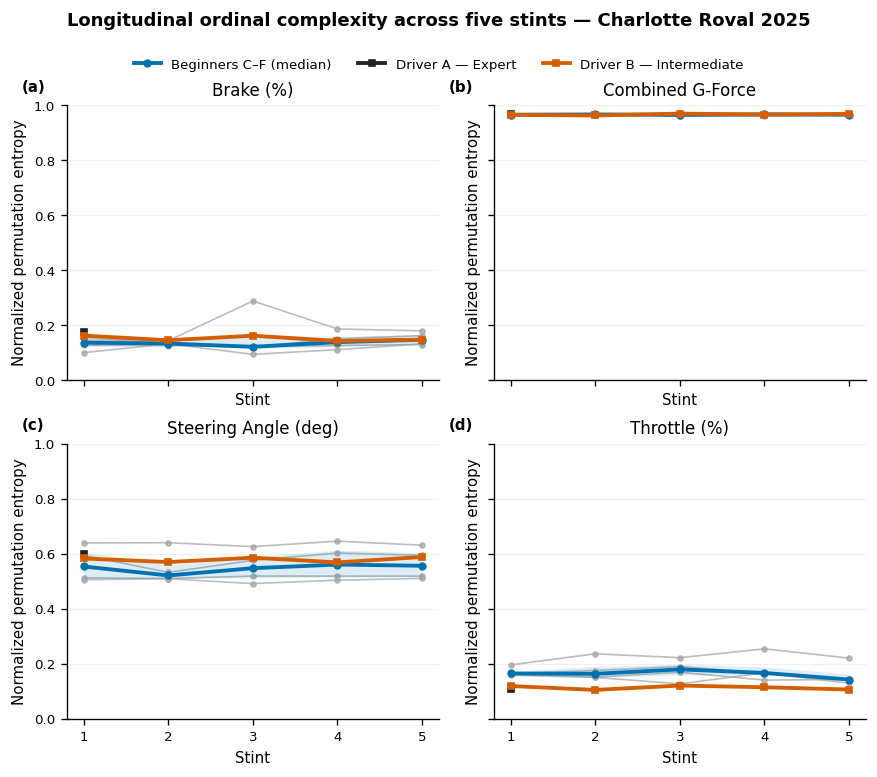

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\permutation_entropy_stints_1_5_v5\figures\Fig_6_2_longitudinal_PE_summit_point.pdf


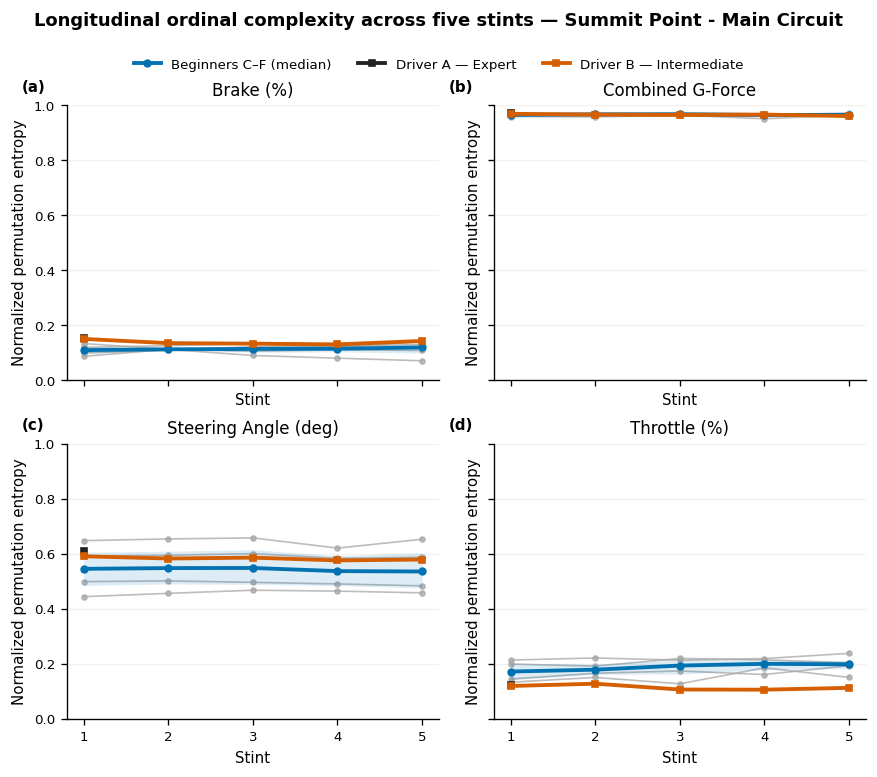

In [14]:

# Figure 1 — Section 6.2 candidate:
# Longitudinal normalized PE level across Stints 1–5

def plot_longitudinal_pe(track_id: str):
    track_name = TRACK_META[track_id]["track_name"]
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(7.2, 5.8),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    axes = axes.ravel()

    alias_a = DRIVER_TIER["Rodrigo"]["alias"]
    alias_b = DRIVER_TIER["Tomaz"]["alias"]

    for ax, variable in zip(axes, VAR_LABELS):
        # Individual beginners: thin, low-salience context.
        beginner_df = PE_STINT[
            (PE_STINT["Track"] == track_id)
            & (PE_STINT["Tier"] == "Beginner")
            & (PE_STINT["Variable"] == variable)
        ]
        for alias, driver_df in beginner_df.groupby("Alias", observed=True):
            driver_df = driver_df.sort_values("Stint")
            ax.plot(
                driver_df["Stint"],
                driver_df["PE_mean"],
                color=COLORS["Individuals"],
                linewidth=1.0,
                marker="o",
                markersize=3,
                alpha=0.75,
                zorder=1,
            )

        # Beginner group median + inter-driver IQR.
        group_df = AMATEUR_STINT[
            (AMATEUR_STINT["Track"] == track_id)
            & (AMATEUR_STINT["Variable"] == variable)
        ].sort_values("Stint")
        if not group_df.empty:
            x = group_df["Stint"].to_numpy()
            y = group_df["PE_group_median"].to_numpy()
            q25 = group_df["PE_group_q25"].to_numpy()
            q75 = group_df["PE_group_q75"].to_numpy()
            ax.fill_between(
                x,
                q25,
                q75,
                color=COLORS["Beginner group"],
                alpha=0.13,
                linewidth=0,
                zorder=2,
            )
            ax.plot(
                x,
                y,
                color=COLORS["Beginner group"],
                linewidth=2.3,
                marker="o",
                markersize=4,
                label="Beginners C–F (median)",
                zorder=4,
            )

        # Expert and intermediate foreground.
        for alias, color, label in [
            (alias_a, COLORS["Driver A"], "Driver A — Expert"),
            (alias_b, COLORS["Driver B"], "Driver B — Intermediate"),
        ]:
            driver_df = PE_STINT[
                (PE_STINT["Track"] == track_id)
                & (PE_STINT["Alias"] == alias)
                & (PE_STINT["Variable"] == variable)
            ].sort_values("Stint")

            if driver_df.empty:
                continue

            ax.plot(
                driver_df["Stint"],
                driver_df["PE_mean"],
                color=color,
                linewidth=2.3,
                marker="s",
                markersize=4,
                label=label,
                zorder=5,
            )

        ax.set_title(variable)
        ax.set_xlim(0.8, 5.2)
        ax.set_ylim(0.0, 1.0)
        ax.set_xticks(STINT_NUMBERS)
        ax.set_xlabel("Stint")
        ax.set_ylabel("Normalized permutation entropy")
        ax.grid(axis="y", alpha=0.18, linewidth=0.7)

    add_panel_letters(axes)

    handles, labels = axes[0].get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    fig.legend(
        unique.values(),
        unique.keys(),
        loc="upper center",
        bbox_to_anchor=(0.5, 1.04),
        ncol=3,
        frameon=False,
    )
    fig.suptitle(
        f"Longitudinal ordinal complexity across five stints — {track_name}",
        y=1.09,
        fontweight="bold",
    )
    save_publication_figure(
        fig,
        f"Fig_6_2_longitudinal_PE_{track_id}",
    )
    plt.show()


for track_id in BATCH_TRACKS:
    plot_longitudinal_pe(track_id)


Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\permutation_entropy_stints_1_5_v5\figures\Fig_6_4_reference_distance_charlotte_roval_2025.pdf


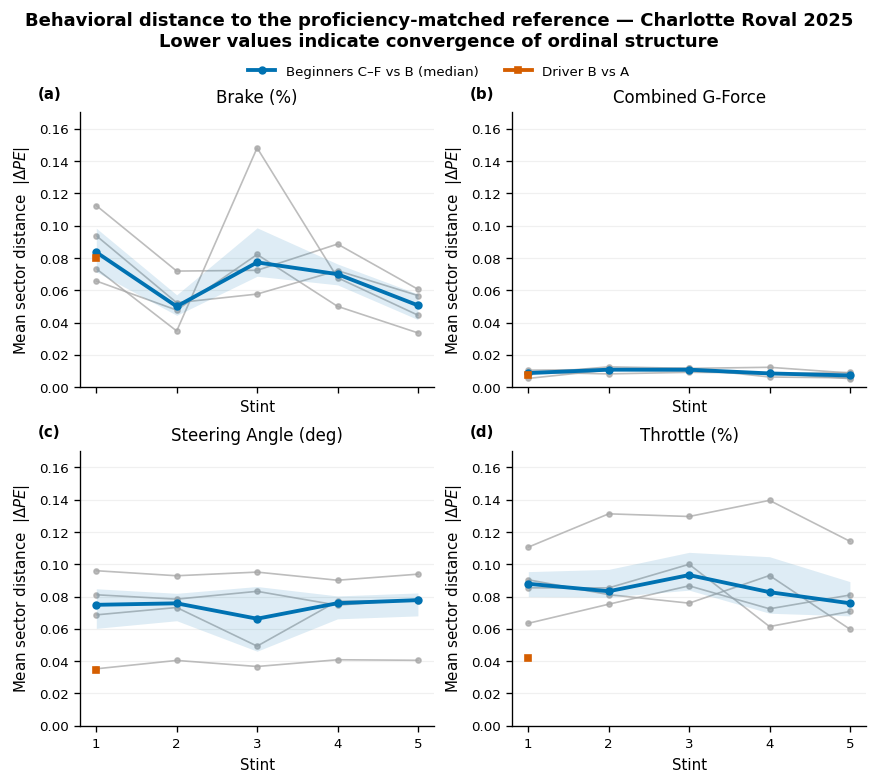

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\permutation_entropy_stints_1_5_v5\figures\Fig_6_4_reference_distance_summit_point.pdf


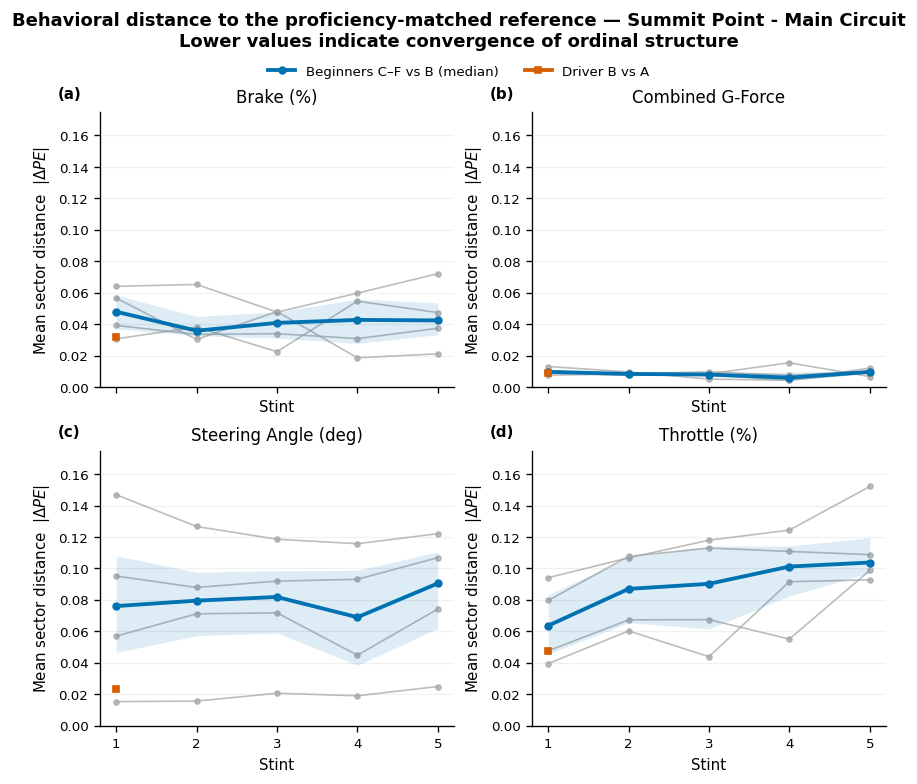

In [15]:

# Figure 2 — Section 6.4 candidate:
# Reference-distance evolution. Lower MeanAbsDeltaPE means closer ordinal structure.

def plot_reference_distance(track_id: str):
    track_name = TRACK_META[track_id]["track_name"]
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(7.2, 5.8),
        sharex=True,
        constrained_layout=True,
    )
    axes = axes.ravel()

    track_values = PAIR_SUMMARY[
        PAIR_SUMMARY["Track"] == track_id
    ]["MeanAbsDeltaPE"]
    ymax = max(0.08, float(track_values.max()) * 1.15) if len(track_values) else 0.2

    for ax, variable in zip(axes, VAR_LABELS):
        # Each beginner compared with Driver B.
        beginner_pairs = PAIR_SUMMARY[
            (PAIR_SUMMARY["Track"] == track_id)
            & (PAIR_SUMMARY["Variable"] == variable)
            & (PAIR_SUMMARY["Comparison"].isin(["C_vs_B", "D_vs_B", "E_vs_B", "F_vs_B"]))
        ]

        for comparison, comp_df in beginner_pairs.groupby(
            "Comparison", observed=True
        ):
            comp_df = comp_df.sort_values("Stint")
            ax.plot(
                comp_df["Stint"],
                comp_df["MeanAbsDeltaPE"],
                color=COLORS["Individuals"],
                linewidth=1.0,
                marker="o",
                markersize=3,
                alpha=0.75,
                zorder=1,
            )

        # Beginner median + IQR.
        group_df = AMATEUR_DISTANCE[
            (AMATEUR_DISTANCE["Track"] == track_id)
            & (AMATEUR_DISTANCE["Variable"] == variable)
        ].sort_values("Stint")
        if not group_df.empty:
            x = group_df["Stint"].to_numpy()
            y = group_df["MeanAbsDeltaPE_group_median"].to_numpy()
            q25 = group_df["MeanAbsDeltaPE_group_q25"].to_numpy()
            q75 = group_df["MeanAbsDeltaPE_group_q75"].to_numpy()
            ax.fill_between(
                x,
                q25,
                q75,
                color=COLORS["Beginner group"],
                alpha=0.13,
                linewidth=0,
                zorder=2,
            )
            ax.plot(
                x,
                y,
                color=COLORS["Beginner group"],
                linewidth=2.3,
                marker="o",
                markersize=4,
                label="Beginners C–F vs B (median)",
                zorder=4,
            )

        # Driver B compared with Driver A.
        ba_df = PAIR_SUMMARY[
            (PAIR_SUMMARY["Track"] == track_id)
            & (PAIR_SUMMARY["Variable"] == variable)
            & (PAIR_SUMMARY["Comparison"] == "B_vs_A")
        ].sort_values("Stint")
        if not ba_df.empty:
            ax.plot(
                ba_df["Stint"],
                ba_df["MeanAbsDeltaPE"],
                color=COLORS["Driver B"],
                linewidth=2.3,
                marker="s",
                markersize=4,
                label="Driver B vs A",
                zorder=5,
            )

        ax.set_title(variable)
        ax.set_xlim(0.8, 5.2)
        ax.set_ylim(0.0, ymax)
        ax.set_xticks(STINT_NUMBERS)
        ax.set_xlabel("Stint")
        ax.set_ylabel(r"Mean sector distance  $|\Delta PE|$")
        ax.grid(axis="y", alpha=0.18, linewidth=0.7)

    add_panel_letters(axes)
    handles, labels = axes[0].get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    fig.legend(
        unique.values(),
        unique.keys(),
        loc="upper center",
        bbox_to_anchor=(0.5, 1.04),
        ncol=2,
        frameon=False,
    )
    fig.suptitle(
        f"Behavioral distance to the proficiency-matched reference — {track_name}\n"
        "Lower values indicate convergence of ordinal structure",
        y=1.10,
        fontweight="bold",
    )
    save_publication_figure(
        fig,
        f"Fig_6_4_reference_distance_{track_id}",
    )
    plt.show()


for track_id in BATCH_TRACKS:
    plot_reference_distance(track_id)


Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\permutation_entropy_stints_1_5_v5\figures\Fig_6_4_sector_stint_DeltaPE_B_vs_A_charlotte_roval_2025.pdf


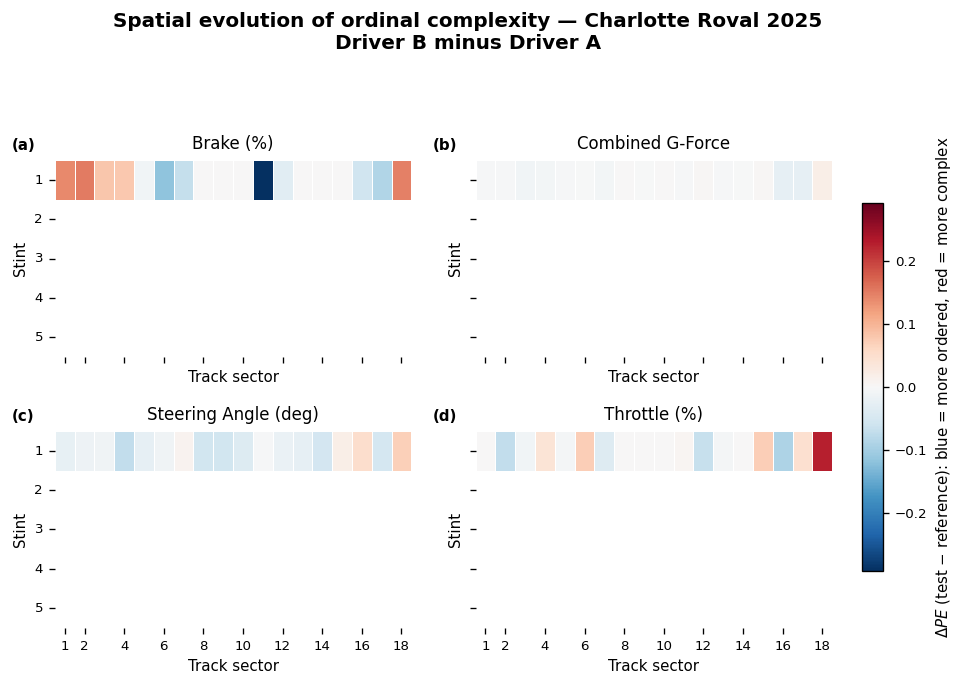

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\permutation_entropy_stints_1_5_v5\figures\Fig_6_4_sector_stint_DeltaPE_beginner_group_charlotte_roval_2025.pdf


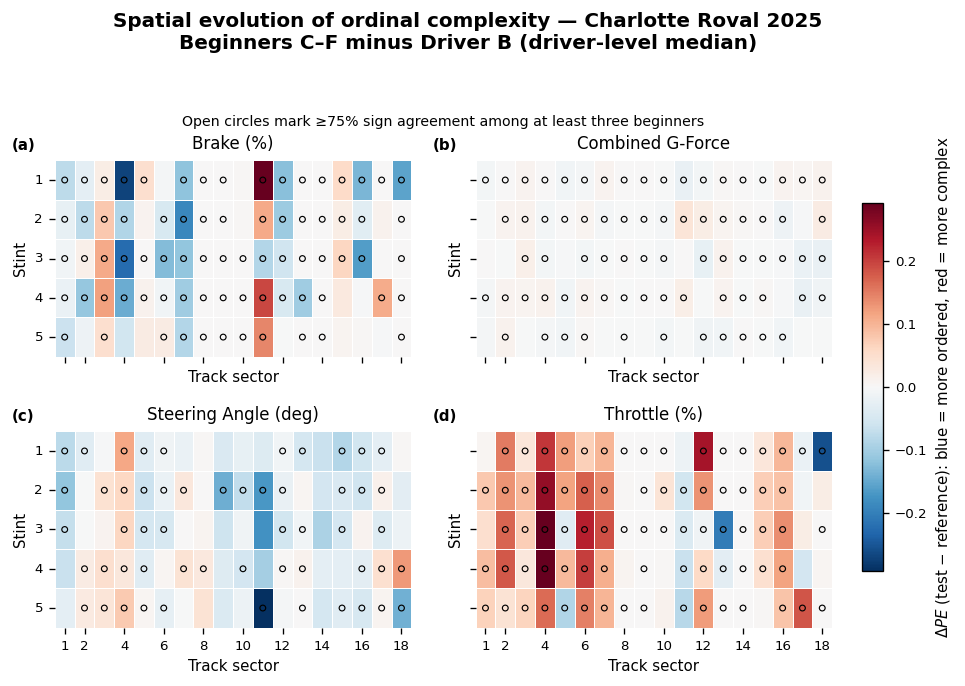

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\permutation_entropy_stints_1_5_v5\figures\Fig_6_4_sector_stint_DeltaPE_B_vs_A_summit_point.pdf


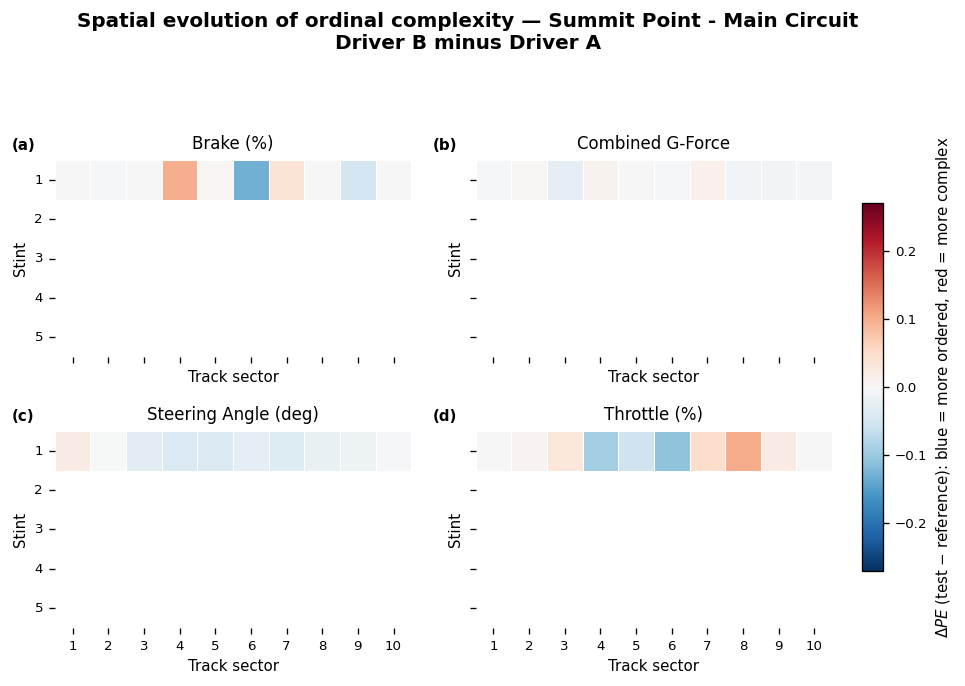

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\permutation_entropy_stints_1_5_v5\figures\Fig_6_4_sector_stint_DeltaPE_beginner_group_summit_point.pdf


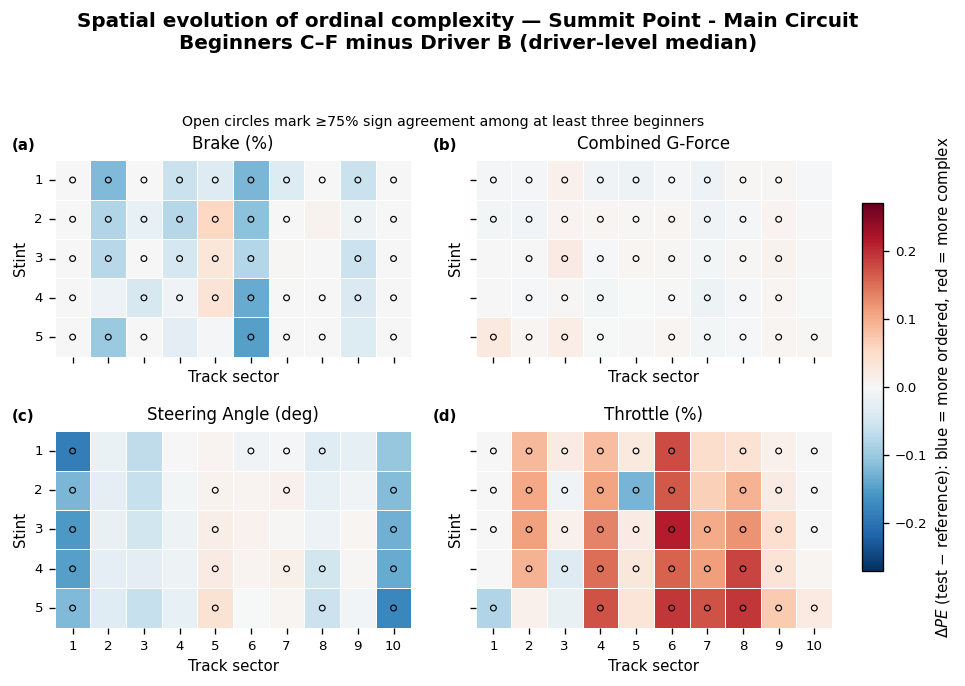

In [16]:

# Figure 3 — Section 6.4 candidate:
# Sector x stint DeltaPE maps. One shared scale supports immediate comparison.

def plot_sector_stint_delta_heatmaps(track_id: str, mode: str):
    track_name = TRACK_META[track_id]["track_name"]
    sector_indices = list(range(1, TRACK_META[track_id]["n_sectors"] + 1))

    track_pair_values = DELTA_PE[
        DELTA_PE["Track"] == track_id
    ]["DeltaPE"]
    track_group_values = AMATEUR_DELTA_SECTOR[
        AMATEUR_DELTA_SECTOR["Track"] == track_id
    ]["DeltaPE_group_median"]
    vlim = common_delta_limit(
        pd.concat([track_pair_values, track_group_values], ignore_index=True)
    )

    if mode == "B_vs_A":
        source = DELTA_PE[
            (DELTA_PE["Track"] == track_id)
            & (DELTA_PE["Comparison"] == "B_vs_A")
        ].copy()
        value_col = "DeltaPE"
        title = "Driver B minus Driver A"
        stem = f"Fig_6_4_sector_stint_DeltaPE_B_vs_A_{track_id}"
        consensus = None
        consensus_note = None
    elif mode == "beginner_group":
        source = AMATEUR_DELTA_SECTOR[
            AMATEUR_DELTA_SECTOR["Track"] == track_id
        ].copy()
        value_col = "DeltaPE_group_median"
        title = "Beginners C–F minus Driver B (driver-level median)"
        stem = f"Fig_6_4_sector_stint_DeltaPE_beginner_group_{track_id}"
        consensus = source[
            ["Stint", "SectorIndex", "Variable", "SignAgreement", "N_drivers"]
        ].copy()
        consensus_note = (
            "Open circles mark ≥75% sign agreement among at least three beginners"
        )
    else:
        raise ValueError("mode must be 'B_vs_A' or 'beginner_group'.")

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(8.2, 5.9),
        sharex=True,
        sharey=True,
        constrained_layout=False,
    )
    axes = axes.ravel()
    fig.subplots_adjust(
        left=0.08,
        right=0.87,
        bottom=0.10,
        top=0.76,
        wspace=0.18,
        hspace=0.38,
    )

    for ax, variable in zip(axes, VAR_LABELS):
        variable_df = source[source["Variable"] == variable]
        pivot = (
            variable_df.pivot_table(
                index="Stint",
                columns="SectorIndex",
                values=value_col,
                aggfunc="mean",
            )
            .reindex(index=STINT_NUMBERS, columns=sector_indices)
        )

        sns.heatmap(
            pivot,
            ax=ax,
            cmap="RdBu_r",
            vmin=-vlim,
            vmax=vlim,
            center=0,
            cbar=False,
            linewidths=0.35,
            linecolor="white",
            mask=pivot.isna(),
        )

        if consensus is not None:
            consensus_df = consensus[
                consensus["Variable"] == variable
            ].set_index(["Stint", "SectorIndex"])
            for row_index, stint_no in enumerate(STINT_NUMBERS):
                for col_index, sector_index in enumerate(sector_indices):
                    key = (stint_no, sector_index)
                    if key not in consensus_df.index:
                        continue
                    record = consensus_df.loc[key]
                    if isinstance(record, pd.DataFrame):
                        record = record.iloc[0]
                    if (
                        record["N_drivers"] >= 3
                        and record["SignAgreement"] >= 0.75
                    ):
                        ax.scatter(
                            col_index + 0.5,
                            row_index + 0.5,
                            s=12,
                            facecolor="none",
                            edgecolor="black",
                            linewidth=0.7,
                        )

        ax.set_title(variable, pad=7)
        ax.set_xlabel("Track sector")
        ax.set_ylabel("Stint")
        ax.set_yticklabels(STINT_NUMBERS, rotation=0)

        if len(sector_indices) > 12:
            visible_ticks = [
                index for index in sector_indices
                if index == 1 or index % 2 == 0
            ]
            tick_positions = [index - 0.5 for index in visible_ticks]
            ax.set_xticks(tick_positions)
            ax.set_xticklabels(visible_ticks, rotation=0)
        else:
            ax.set_xticklabels(sector_indices, rotation=0)

    add_panel_letters(axes)

    cbar_ax = fig.add_axes([0.90, 0.18, 0.022, 0.52])
    scalar_map = mpl.cm.ScalarMappable(
        norm=mpl.colors.Normalize(vmin=-vlim, vmax=vlim),
        cmap="RdBu_r",
    )
    scalar_map.set_array([])
    cbar = fig.colorbar(scalar_map, cax=cbar_ax)
    cbar.set_label(
        r"$\Delta PE$ (test − reference): blue = more ordered, red = more complex"
    )

    fig.suptitle(
        f"Spatial evolution of ordinal complexity — {track_name}\n{title}",
        y=0.97,
        fontsize=12,
        fontweight="bold",
    )
    if consensus_note:
        fig.text(
            0.475,
            0.815,
            consensus_note,
            ha="center",
            va="center",
            fontsize=8.5,
        )

    save_publication_figure(fig, stem)
    plt.show()


for track_id in BATCH_TRACKS:
    plot_sector_stint_delta_heatmaps(track_id, "B_vs_A")
    plot_sector_stint_delta_heatmaps(track_id, "beginner_group")


Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\permutation_entropy_stints_1_5_v5\figures\Fig_6_4_beginner_heterogeneity_charlotte_roval_2025.pdf


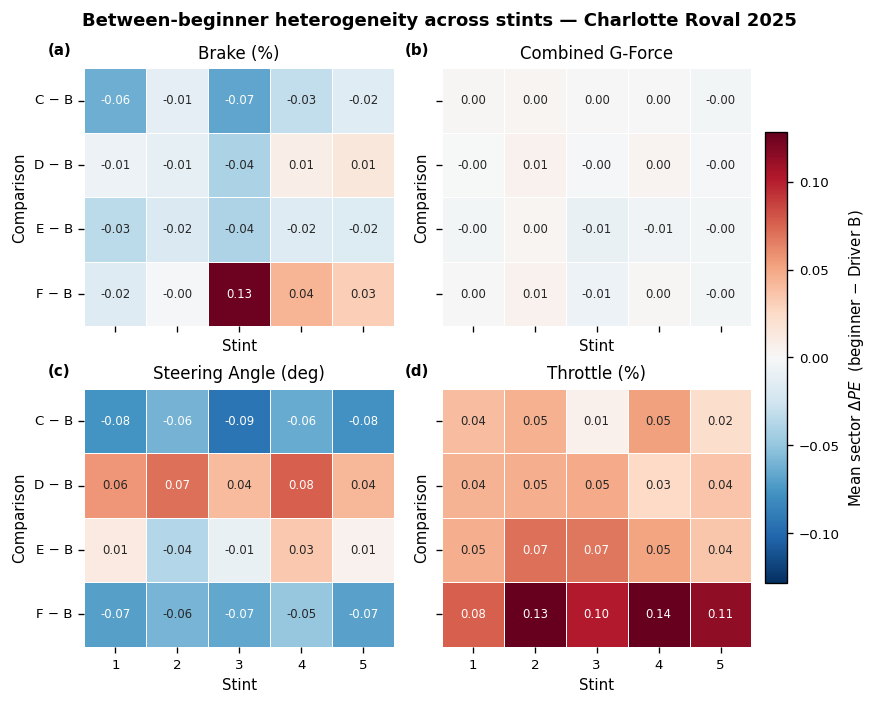

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\permutation_entropy_stints_1_5_v5\figures\Fig_6_4_beginner_heterogeneity_summit_point.pdf


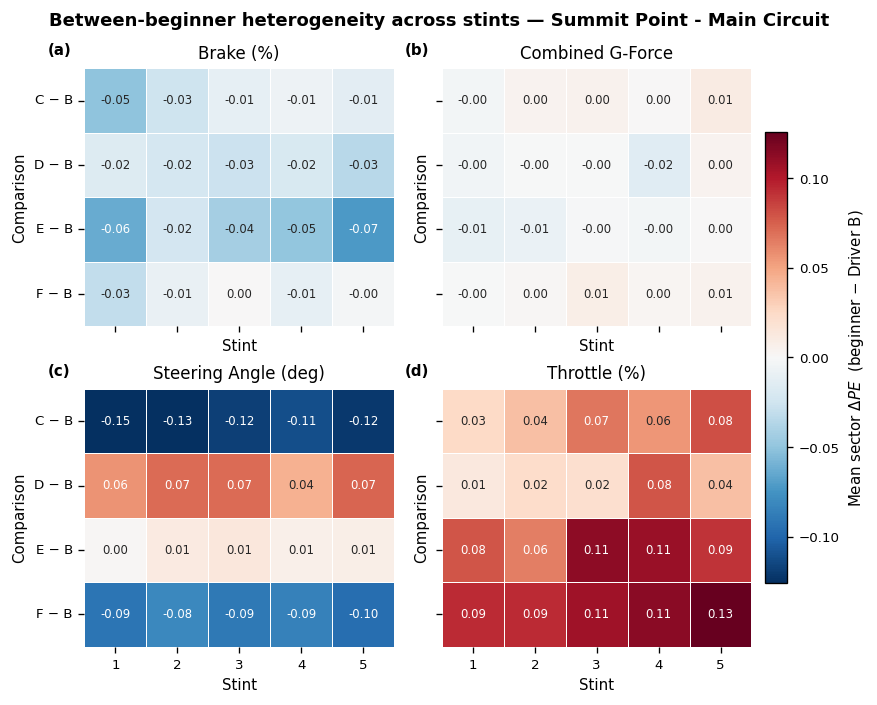

In [17]:

# Figure 4 — Beginner heterogeneity:
# Each beginner is retained as a separate comparison with Driver B.

def plot_beginner_heterogeneity(track_id: str):
    track_name = TRACK_META[track_id]["track_name"]
    beginner_summary = PAIR_SUMMARY[
        (PAIR_SUMMARY["Track"] == track_id)
        & (PAIR_SUMMARY["Comparison"].isin(["C_vs_B", "D_vs_B", "E_vs_B", "F_vs_B"]))
    ].copy()

    vlim = common_delta_limit(beginner_summary["MeanDeltaPE"], minimum=0.03)

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(7.2, 5.5),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    axes = axes.ravel()

    row_order = ["C_vs_B", "D_vs_B", "E_vs_B", "F_vs_B"]

    for ax, variable in zip(axes, VAR_LABELS):
        pivot = (
            beginner_summary[beginner_summary["Variable"] == variable]
            .pivot_table(
                index="Comparison",
                columns="Stint",
                values="MeanDeltaPE",
                aggfunc="mean",
            )
            .reindex(index=row_order, columns=STINT_NUMBERS)
        )
        pivot.index = [COMPARISON_DISPLAY[index] for index in pivot.index]

        sns.heatmap(
            pivot,
            ax=ax,
            cmap="RdBu_r",
            vmin=-vlim,
            vmax=vlim,
            center=0,
            annot=True,
            fmt=".2f",
            annot_kws={"fontsize": 7},
            linewidths=0.6,
            linecolor="white",
            cbar=False,
            mask=pivot.isna(),
        )
        ax.set_title(variable)
        ax.set_xlabel("Stint")
        ax.set_ylabel("Comparison")
        ax.set_xticklabels(STINT_NUMBERS, rotation=0)
        ax.set_yticklabels(pivot.index, rotation=0)

    add_panel_letters(axes)

    scalar_map = mpl.cm.ScalarMappable(
        norm=mpl.colors.Normalize(vmin=-vlim, vmax=vlim),
        cmap="RdBu_r",
    )
    scalar_map.set_array([])
    cbar = fig.colorbar(
        scalar_map,
        ax=axes.tolist(),
        shrink=0.78,
        pad=0.02,
    )
    cbar.set_label(r"Mean sector $\Delta PE$  (beginner − Driver B)")

    fig.suptitle(
        f"Between-beginner heterogeneity across stints — {track_name}",
        y=1.04,
        fontweight="bold",
    )
    save_publication_figure(
        fig,
        f"Fig_6_4_beginner_heterogeneity_{track_id}",
    )
    plt.show()


for track_id in BATCH_TRACKS:
    plot_beginner_heterogeneity(track_id)


Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\permutation_entropy_stints_1_5_v5\figures\Fig_6_4_PE_performance_trajectory_charlotte_roval_2025.pdf


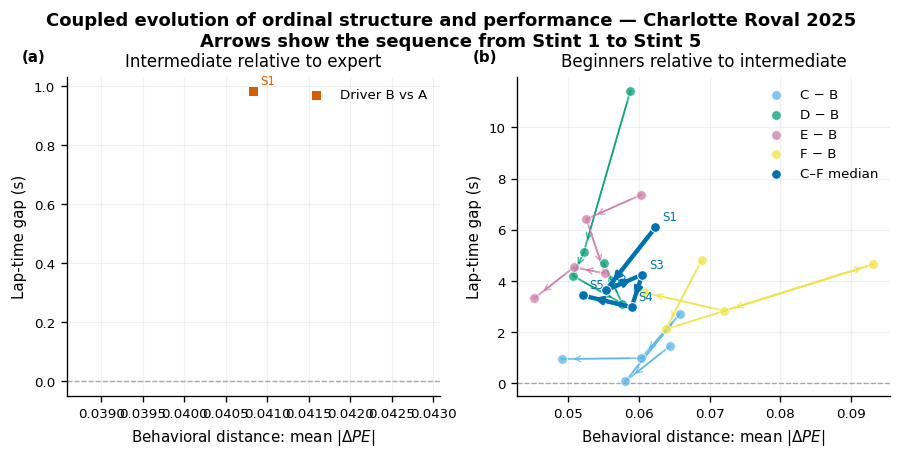

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\permutation_entropy_stints_1_5_v5\figures\Fig_6_4_PE_performance_trajectory_summit_point.pdf


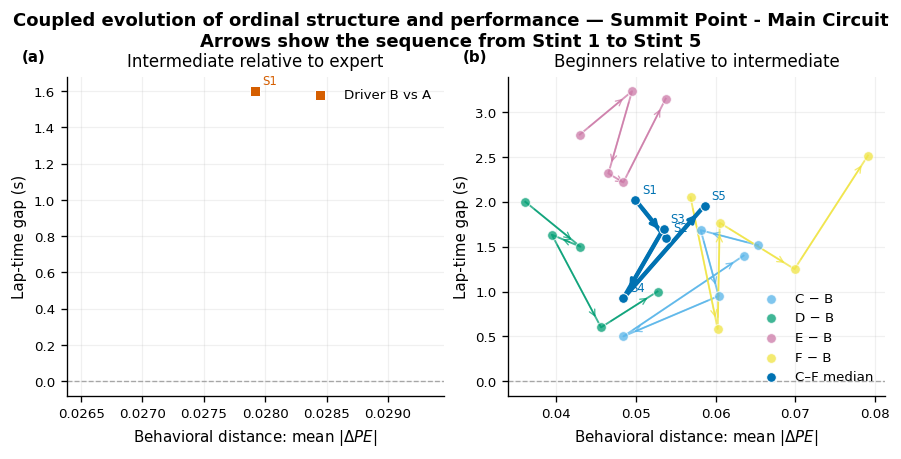

In [18]:

# Figure 5 — Joint behavioral/performance evolution:
# lower-left movement means simultaneous PE convergence and lap-gap reduction.

TRAJECTORY = PAIR_OVERALL.merge(
    PERFORMANCE[
        [
            "Track",
            "Comparison",
            "Stint",
            "LapGap_s",
        ]
    ],
    on=["Track", "Comparison", "Stint"],
    how="inner",
)

TRAJECTORY.to_csv(
    TABLE_DIR / "behavior_performance_trajectory.csv",
    index=False,
)


def draw_ordered_trajectory(
    ax,
    df,
    color,
    label,
    marker="o",
    linewidth=2.0,
    alpha=1.0,
    annotate_stints=True,
    zorder=3,
):
    df = df.sort_values("Stint")
    if df.empty:
        return

    x = df["MeanAbsDeltaPE"].to_numpy()
    y = df["LapGap_s"].to_numpy()

    ax.plot(
        x,
        y,
        color=color,
        linewidth=linewidth,
        alpha=alpha,
        zorder=zorder,
    )
    ax.scatter(
        x,
        y,
        color=color,
        marker=marker,
        s=34,
        edgecolor="white",
        linewidth=0.6,
        alpha=alpha,
        label=label,
        zorder=zorder + 1,
    )

    for index in range(len(df) - 1):
        ax.annotate(
            "",
            xy=(x[index + 1], y[index + 1]),
            xytext=(x[index], y[index]),
            arrowprops={
                "arrowstyle": "->",
                "color": color,
                "lw": max(0.8, linewidth - 0.4),
                "alpha": alpha,
                "shrinkA": 7,
                "shrinkB": 7,
            },
            zorder=zorder,
        )

    if annotate_stints:
        for x_value, y_value, stint_no in zip(x, y, df["Stint"]):
            ax.annotate(
                f"S{int(stint_no)}",
                (x_value, y_value),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=7,
                color=color,
            )


def plot_behavior_performance_trajectory(track_id: str):
    track_name = TRACK_META[track_id]["track_name"]
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(7.4, 3.4),
        constrained_layout=True,
    )

    # Driver B vs Driver A.
    ba_df = TRAJECTORY[
        (TRAJECTORY["Track"] == track_id)
        & (TRAJECTORY["Comparison"] == "B_vs_A")
    ]
    draw_ordered_trajectory(
        axes[0],
        ba_df,
        color=COLORS["Driver B"],
        label="Driver B vs A",
        marker="s",
        linewidth=2.2,
        annotate_stints=True,
    )
    axes[0].set_title("Intermediate relative to expert")

    # Individual beginners vs Driver B.
    beginner_df = TRAJECTORY[
        (TRAJECTORY["Track"] == track_id)
        & (TRAJECTORY["Comparison"].isin(["C_vs_B", "D_vs_B", "E_vs_B", "F_vs_B"]))
    ].copy()

    beginner_colors = {
        "C_vs_B": COLORS["Driver C"],
        "D_vs_B": COLORS["Driver D"],
        "E_vs_B": COLORS["Driver E"],
        "F_vs_B": COLORS["Driver F"],
    }

    for comparison in ["C_vs_B", "D_vs_B", "E_vs_B", "F_vs_B"]:
        comp_df = beginner_df[beginner_df["Comparison"] == comparison]
        draw_ordered_trajectory(
            axes[1],
            comp_df,
            color=beginner_colors[comparison],
            label=COMPARISON_DISPLAY[comparison],
            linewidth=1.15,
            alpha=0.75,
            annotate_stints=False,
            zorder=2,
        )

    # Median beginner trajectory calculated after driver-level summaries.
    group_trajectory = (
        beginner_df.groupby("Stint", as_index=False)
        .agg(
            MeanAbsDeltaPE=("MeanAbsDeltaPE", "median"),
            LapGap_s=("LapGap_s", "median"),
        )
    )
    draw_ordered_trajectory(
        axes[1],
        group_trajectory,
        color=COLORS["Beginner group"],
        label="C–F median",
        linewidth=2.6,
        alpha=1.0,
        annotate_stints=True,
        zorder=5,
    )
    axes[1].set_title("Beginners relative to intermediate")

    for ax in axes:
        ax.axhline(0, color="0.65", linewidth=0.8, linestyle="--")
        ax.set_xlabel(r"Behavioral distance: mean $|\Delta PE|$")
        ax.set_ylabel("Lap-time gap (s)")
        ax.grid(alpha=0.18, linewidth=0.7)
        ax.legend(frameon=False, loc="best")

    add_panel_letters(axes)
    fig.suptitle(
        f"Coupled evolution of ordinal structure and performance — {track_name}\n"
        "Arrows show the sequence from Stint 1 to Stint 5",
        y=1.08,
        fontweight="bold",
    )
    save_publication_figure(
        fig,
        f"Fig_6_4_PE_performance_trajectory_{track_id}",
    )
    plt.show()


for track_id in BATCH_TRACKS:
    plot_behavior_performance_trajectory(track_id)


Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\permutation_entropy_stints_1_5_v5\figures\Fig_6_4_correlation_evolution_charlotte_roval_2025.pdf


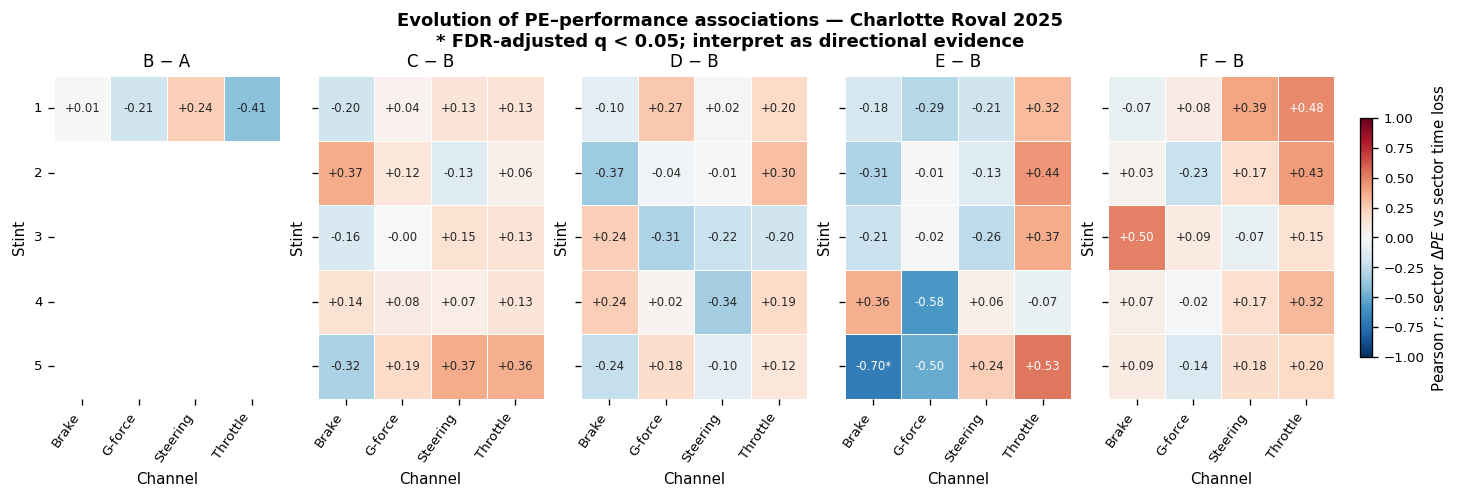

Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\permutation_entropy_stints_1_5_v5\figures\Fig_6_4_correlation_evolution_summit_point.pdf


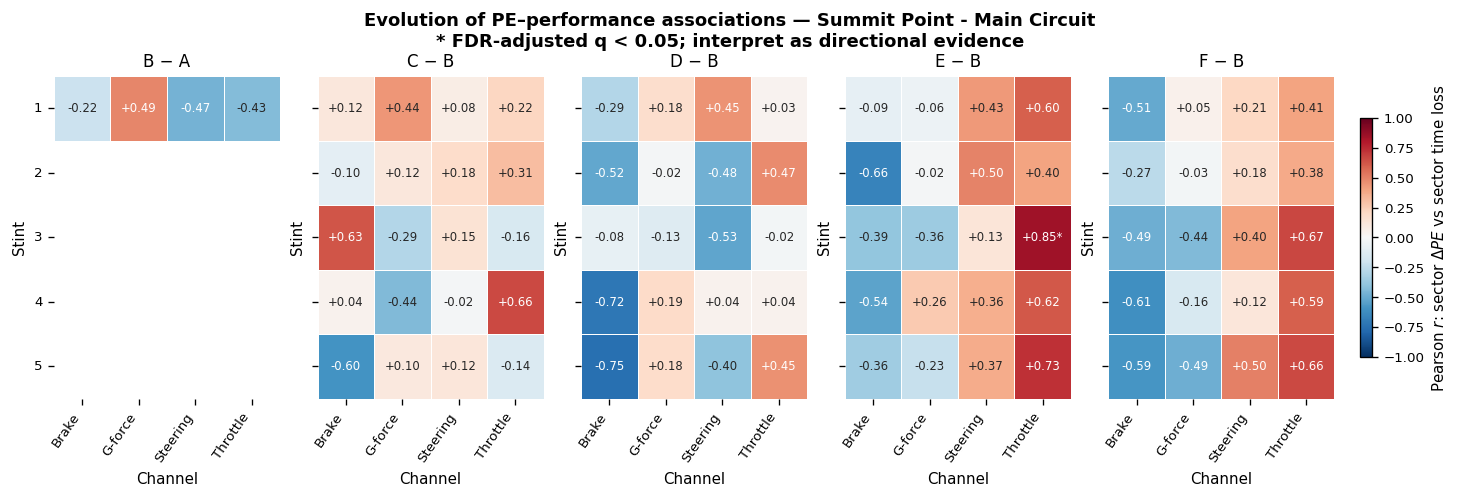

In [19]:

# Figure 6 — Section 6.4 / supplementary candidate:
# Direction and stability of DeltaPE–time-loss associations across stints.
# This figure reports association, not prediction.

def plot_correlation_evolution(track_id: str):
    if CORR_SUMMARY.empty:
        print("Correlation summary is empty; skipping correlation figure.")
        return

    track_corr = CORR_SUMMARY[
        CORR_SUMMARY["Track"] == track_id
    ].copy()

    if track_corr.empty or not np.isfinite(track_corr["Pearson_r"]).any():
        print(
            f"No finite sector-level correlations for {track_id}; "
            "correlation figure was not generated."
        )
        return

    track_name = TRACK_META[track_id]["track_name"]
    available_comparisons = [
        comparison
        for comparison in COMPARISON_ORDER
        if comparison in track_corr["Comparison"].unique()
        and np.isfinite(
            track_corr.loc[
                track_corr["Comparison"] == comparison,
                "Pearson_r",
            ]
        ).any()
    ]
    if not available_comparisons:
        return

    fig, axes = plt.subplots(
        1,
        len(available_comparisons),
        figsize=(2.25 * len(available_comparisons) + 0.8, 3.7),
        sharey=True,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes)

    for ax, comparison in zip(axes, available_comparisons):
        comp_df = track_corr[
            track_corr["Comparison"] == comparison
        ].copy()

        pivot = (
            comp_df.pivot_table(
                index="Stint",
                columns="Variable",
                values="Pearson_r",
                aggfunc="mean",
            )
            .reindex(index=STINT_NUMBERS, columns=VAR_LABELS)
        )

        annotations = pivot.copy().astype(object)
        for stint_no in STINT_NUMBERS:
            for variable in VAR_LABELS:
                value = pivot.loc[stint_no, variable]
                if pd.isna(value):
                    annotations.loc[stint_no, variable] = ""
                    continue
                row = comp_df[
                    (comp_df["Stint"] == stint_no)
                    & (comp_df["Variable"] == variable)
                ]
                significant = (
                    not row.empty
                    and bool(row.iloc[0]["Pearson_sig_FDR"])
                )
                annotations.loc[stint_no, variable] = (
                    f"{value:+.2f}{'*' if significant else ''}"
                )

        sns.heatmap(
            pivot,
            ax=ax,
            cmap="RdBu_r",
            vmin=-1,
            vmax=1,
            center=0,
            annot=annotations,
            fmt="",
            annot_kws={"fontsize": 7},
            linewidths=0.5,
            linecolor="white",
            cbar=False,
            mask=pivot.isna(),
        )
        ax.set_title(COMPARISON_DISPLAY[comparison])
        ax.set_xlabel("Channel")
        ax.set_ylabel("Stint")
        ax.set_yticklabels(STINT_NUMBERS, rotation=0)
        ax.set_xticklabels(
            ["Brake", "G-force", "Steering", "Throttle"],
            rotation=55,
            ha="right",
        )

    scalar_map = mpl.cm.ScalarMappable(
        norm=mpl.colors.Normalize(vmin=-1, vmax=1),
        cmap="RdBu_r",
    )
    scalar_map.set_array([])
    cbar = fig.colorbar(
        scalar_map,
        ax=axes.tolist(),
        shrink=0.74,
        pad=0.02,
    )
    cbar.set_label(r"Pearson $r$: sector $\Delta PE$ vs sector time loss")

    fig.suptitle(
        f"Evolution of PE–performance associations — {track_name}\n"
        "* FDR-adjusted q < 0.05; interpret as directional evidence",
        y=1.08,
        fontweight="bold",
    )
    save_publication_figure(
        fig,
        f"Fig_6_4_correlation_evolution_{track_id}",
    )
    plt.show()


for track_id in BATCH_TRACKS:
    plot_correlation_evolution(track_id)


In [20]:

# 6. Automated longitudinal change table and article-ready descriptive digest

def classify_joint_change(delta_distance: float, delta_gap: float) -> str:
    if not np.isfinite(delta_distance) or not np.isfinite(delta_gap):
        return "Incomplete"
    if delta_distance < 0 and delta_gap < 0:
        return "PE convergence + performance improvement"
    if delta_distance < 0 and delta_gap >= 0:
        return "PE convergence without performance improvement"
    if delta_distance >= 0 and delta_gap < 0:
        return "Performance improvement without PE convergence"
    return "PE divergence + performance regression"


change_rows = []

for track_id in BATCH_TRACKS:
    # Individual pair changes.
    for comparison in COMPARISON_ORDER:
        dist_df = PAIR_OVERALL[
            (PAIR_OVERALL["Track"] == track_id)
            & (PAIR_OVERALL["Comparison"] == comparison)
        ].set_index("Stint")

        perf_df = PERFORMANCE[
            (PERFORMANCE["Track"] == track_id)
            & (PERFORMANCE["Comparison"] == comparison)
        ].set_index("Stint")

        if 1 not in dist_df.index or 5 not in dist_df.index:
            continue
        if 1 not in perf_df.index or 5 not in perf_df.index:
            continue

        distance_s1 = float(dist_df.loc[1, "MeanAbsDeltaPE"])
        distance_s5 = float(dist_df.loc[5, "MeanAbsDeltaPE"])
        gap_s1 = float(perf_df.loc[1, "LapGap_s"])
        gap_s5 = float(perf_df.loc[5, "LapGap_s"])

        var_change = PAIR_SUMMARY[
            (PAIR_SUMMARY["Track"] == track_id)
            & (PAIR_SUMMARY["Comparison"] == comparison)
            & (PAIR_SUMMARY["Stint"].isin([1, 5]))
        ].pivot_table(
            index="Variable",
            columns="Stint",
            values="MeanAbsDeltaPE",
            aggfunc="mean",
        )

        if 1 in var_change.columns and 5 in var_change.columns:
            var_change["Change_S5_minus_S1"] = var_change[5] - var_change[1]
            top_converging_channel = var_change["Change_S5_minus_S1"].idxmin()
            top_diverging_channel = var_change["Change_S5_minus_S1"].idxmax()
        else:
            top_converging_channel = np.nan
            top_diverging_channel = np.nan

        delta_distance = distance_s5 - distance_s1
        delta_gap = gap_s5 - gap_s1

        change_rows.append(
            {
                "Track": track_id,
                "TrackName": TRACK_META[track_id]["track_name"],
                "Comparison": comparison,
                "Distance_S1": distance_s1,
                "Distance_S5": distance_s5,
                "DeltaDistance_S5_minus_S1": delta_distance,
                "LapGap_S1_s": gap_s1,
                "LapGap_S5_s": gap_s5,
                "DeltaLapGap_S5_minus_S1_s": delta_gap,
                "TopConvergingChannel": top_converging_channel,
                "TopDivergingChannel": top_diverging_channel,
                "JointPattern": classify_joint_change(delta_distance, delta_gap),
            }
        )

    # Beginner-group median, calculated from the four driver-level comparisons.
    beginner_dist = PAIR_OVERALL[
        (PAIR_OVERALL["Track"] == track_id)
        & (PAIR_OVERALL["Comparison"].isin(["C_vs_B", "D_vs_B", "E_vs_B", "F_vs_B"]))
    ]
    beginner_perf = PERFORMANCE[
        (PERFORMANCE["Track"] == track_id)
        & (PERFORMANCE["Comparison"].isin(["C_vs_B", "D_vs_B", "E_vs_B", "F_vs_B"]))
    ]

    group_dist = beginner_dist.groupby("Stint")["MeanAbsDeltaPE"].median()
    group_perf = beginner_perf.groupby("Stint")["LapGap_s"].median()

    if all(stint in group_dist.index for stint in [1, 5]) and all(
        stint in group_perf.index for stint in [1, 5]
    ):
        distance_s1 = float(group_dist.loc[1])
        distance_s5 = float(group_dist.loc[5])
        gap_s1 = float(group_perf.loc[1])
        gap_s5 = float(group_perf.loc[5])
        delta_distance = distance_s5 - distance_s1
        delta_gap = gap_s5 - gap_s1

        change_rows.append(
            {
                "Track": track_id,
                "TrackName": TRACK_META[track_id]["track_name"],
                "Comparison": "C-F_median_vs_B",
                "Distance_S1": distance_s1,
                "Distance_S5": distance_s5,
                "DeltaDistance_S5_minus_S1": delta_distance,
                "LapGap_S1_s": gap_s1,
                "LapGap_S5_s": gap_s5,
                "DeltaLapGap_S5_minus_S1_s": delta_gap,
                "TopConvergingChannel": np.nan,
                "TopDivergingChannel": np.nan,
                "JointPattern": classify_joint_change(delta_distance, delta_gap),
            }
        )

LONGITUDINAL_CHANGE = pd.DataFrame(change_rows)
LONGITUDINAL_CHANGE.to_csv(
    TABLE_DIR / "longitudinal_change_stint1_to_stint5.csv",
    index=False,
)
display(LONGITUDINAL_CHANGE)


def print_results_digest():
    print("\nARTICLE-READY DESCRIPTIVE DIGEST")
    print("=" * 72)

    for track_id in BATCH_TRACKS:
        track_name = TRACK_META[track_id]["track_name"]
        print(f"\n{track_name}")

        track_df = LONGITUDINAL_CHANGE[
            LONGITUDINAL_CHANGE["Track"] == track_id
        ]
        for comparison in ["B_vs_A", "C-F_median_vs_B"]:
            row = track_df[track_df["Comparison"] == comparison]
            if row.empty:
                continue
            row = row.iloc[0]

            comparison_text = (
                "Driver B relative to Driver A"
                if comparison == "B_vs_A"
                else "the beginner-group median relative to Driver B"
            )

            print(
                f"- {comparison_text}: mean absolute DeltaPE changed from "
                f"{row['Distance_S1']:.3f} in Stint 1 to "
                f"{row['Distance_S5']:.3f} in Stint 5 "
                f"(change {row['DeltaDistance_S5_minus_S1']:+.3f}). "
                f"The lap-time gap changed from {row['LapGap_S1_s']:+.3f} s "
                f"to {row['LapGap_S5_s']:+.3f} s "
                f"(change {row['DeltaLapGap_S5_minus_S1_s']:+.3f} s). "
                f"Descriptive pattern: {row['JointPattern']}."
            )


print_results_digest()


,Track,TrackName,Comparison,Distance_S1,Distance_S5,DeltaDistance_S5_minus_S1,LapGap_S1_s,LapGap_S5_s,DeltaLapGap_S5_minus_S1_s,TopConvergingChannel,TopDivergingChannel,JointPattern
0,charlotte_roval_2025,Charlotte Roval 2025,C_vs_B,0.064361,0.049057,-0.015304,1.450000,0.950000,-0.500000,Brake (%),Combined G-Force,PE convergence + performance improvement
1,charlotte_roval_2025,Charlotte Roval 2025,D_vs_B,0.058766,0.054992,-0.003774,11.416667,4.700000,-6.716667,Brake (%),Throttle (%),PE convergence + performance improvement
2,charlotte_roval_2025,Charlotte Roval 2025,E_vs_B,0.060299,0.045141,-0.015158,7.366667,3.316667,-4.050000,Brake (%),Steering Angle (deg),PE convergence + performance improvement
3,charlotte_roval_2025,Charlotte Roval 2025,F_vs_B,0.068857,0.060701,-0.008156,4.816667,3.550000,-1.266667,Brake (%),Throttle (%),PE convergence + performance improvement
4,charlotte_roval_2025,Charlotte Roval 2025,C-F_median_vs_B,0.062330,0.052025,-0.010305,6.091667,3.433333,-2.658333,NaN,NaN,PE convergence + performance improvement
5,summit_point,Summit Point - Main Circuit,C_vs_B,0.065321,0.063514,-0.001807,1.516667,1.400000,-0.116667,Brake (%),Throttle (%),PE convergence + performance improvement
6,summit_point,Summit Point - Main Circuit,D_vs_B,0.036185,0.052734,0.016549,2.000000,1.000000,-1.000000,Combined G-Force,Throttle (%),Performance improvement without PE convergence
7,summit_point,Summit Point - Main Circuit,E_vs_B,0.043005,0.053756,0.010751,2.750000,3.150000,0.400000,Combined G-Force,Throttle (%),PE divergence + performance regression
8,summit_point,Summit Point - Main Circuit,F_vs_B,0.056874,0.079094,0.022220,2.050000,2.516667,0.466667,Combined G-Force,Throttle (%),PE divergence + performance regression
9,summit_point,Summit Point - Main Circuit,C-F_median_vs_B,0.049939,0.058635,0.008696,2.025000,1.958333,-0.066667,NaN,NaN,Performance improvement without PE convergence



ARTICLE-READY DESCRIPTIVE DIGEST

Charlotte Roval 2025
- the beginner-group median relative to Driver B: mean absolute DeltaPE changed from 0.062 in Stint 1 to 0.052 in Stint 5 (change -0.010). The lap-time gap changed from +6.092 s to +3.433 s (change -2.658 s). Descriptive pattern: PE convergence + performance improvement.

Summit Point - Main Circuit
- the beginner-group median relative to Driver B: mean absolute DeltaPE changed from 0.050 in Stint 1 to 0.059 in Stint 5 (change +0.009). The lap-time gap changed from +2.025 s to +1.958 s (change -0.067 s). Descriptive pattern: Performance improvement without PE convergence.



## 7. Recommended manuscript use

### Section 6.2 — Longitudinal Ordinal Complexity

Recommended title: **“Longitudinal Evolution of Ordinal Control Complexity”**.

Use **Figure 1** as the main section figure. It answers three questions in one aligned visual
system:

1. whether Driver B maintains the same PE level as Driver A across Stints 1–5;
2. whether the beginner-group median changes across practice;
3. whether the group median hides large differences among Drivers C–F.

The wording should use **ordinal complexity**, **temporal organization**, or **control
structure**. Avoid equating PE directly with “uncertainty,” “randomness,” or “skill.”
A monotonic or plateau-heavy control sequence can have low PE without being fast, while
structured trail-braking modulation can increase PE without being disruptive.

A defensible paragraph structure is:

> Normalized PE was first examined as a within-driver descriptor across the five stints.
> The expert and intermediate profiles were compared with the beginner-group median while
> retaining each beginner as an individual trajectory. Changes in PE were interpreted as
> changes in ordinal control structure, not as direct changes in skill.

After execution, use `LONGITUDINAL_CHANGE` and the printed descriptive digest to insert the
actual directions and magnitudes.



### Section 6.4 — Reference-Relative PE and Performance Coupling

Recommended subsection structure:

**6.4.1 Reference-relative convergence across stints.**  
Use **Figure 2**. The outcome is mean sector \(|\Delta PE|\): lower values indicate that the
test driver’s ordinal pattern distribution is closer to the proficiency-matched reference.

**6.4.2 Spatial persistence and relocation of complexity.**  
Use **Figure 3**. Rows are stints and columns are circuit sectors, so vertical patterns reveal
persistent hotspots and horizontal changes reveal relocation across practice. In the
beginner-group map, open circles identify sign agreement in at least three of four drivers.

**6.4.3 Heterogeneity among beginners.**  
Use **Figure 4** or place it in supplementary material. It prevents a group median from being
described as a universal beginner response.

**6.4.4 Coupling with performance.**  
Use **Figure 5** to distinguish four longitudinal patterns: PE convergence with improvement,
PE convergence without improvement, improvement without PE convergence, and joint
divergence/regression.

**6.4.5 Sector-level association.**  
Use **Figure 6** as supplementary evidence. Replace the term *predictor* with *association*
unless an actual predictive model with out-of-sample validation is fitted. With 10 or 18
sectors and repeated observations from the same drivers, Pearson \(r\) is directional
evidence rather than a population-level effect estimate.


In [21]:

# 7.1 Export concise LaTeX tables and figure include snippets

latex_tables = {
    "table_pe_quality.tex": PE_QUALITY[
        [
            "TrackName",
            "Variable",
            "ValidFraction",
            "PlateauFractionMedian",
            "MedianPatterns",
        ]
    ],
    "table_longitudinal_change.tex": LONGITUDINAL_CHANGE[
        [
            "TrackName",
            "Comparison",
            "Distance_S1",
            "Distance_S5",
            "DeltaDistance_S5_minus_S1",
            "LapGap_S1_s",
            "LapGap_S5_s",
            "DeltaLapGap_S5_minus_S1_s",
            "JointPattern",
        ]
    ],
}

for filename, table in latex_tables.items():
    latex_text = table.to_latex(
        index=False,
        float_format=lambda value: f"{value:.3f}",
        escape=True,
    )
    (TABLE_DIR / filename).write_text(latex_text, encoding="utf-8")
    print(f"Saved: {TABLE_DIR / filename}")


def print_latex_figure_snippets():
    print("\nSuggested LaTeX include commands")
    print("=" * 72)
    for track_id in BATCH_TRACKS:
        stems = [
            f"Fig_6_2_longitudinal_PE_{track_id}",
            f"Fig_6_4_reference_distance_{track_id}",
            f"Fig_6_4_sector_stint_DeltaPE_B_vs_A_{track_id}",
            f"Fig_6_4_sector_stint_DeltaPE_beginner_group_{track_id}",
            f"Fig_6_4_beginner_heterogeneity_{track_id}",
            f"Fig_6_4_PE_performance_trajectory_{track_id}",
            f"Fig_6_4_correlation_evolution_{track_id}",
        ]
        for stem in stems:
            print(
                rf"\includegraphics[width=\linewidth]"
                rf"{{figures/{stem}.pdf}}"
            )


print_latex_figure_snippets()


Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\permutation_entropy_stints_1_5_v5\tables\table_pe_quality.tex
Saved: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\permutation_entropy_stints_1_5_v5\tables\table_longitudinal_change.tex

Suggested LaTeX include commands
\includegraphics[width=\linewidth]{figures/Fig_6_2_longitudinal_PE_charlotte_roval_2025.pdf}
\includegraphics[width=\linewidth]{figures/Fig_6_4_reference_distance_charlotte_roval_2025.pdf}
\includegraphics[width=\linewidth]{figures/Fig_6_4_sector_stint_DeltaPE_B_vs_A_charlotte_roval_2025.pdf}
\includegraphics[width=\linewidth]{figures/Fig_6_4_sector_stint_DeltaPE_beginner_group_charlotte_roval_2025.pdf}
\includegraphics[width=\linewidth]{figures/Fig_6_4_beginner_heterogeneity_charlotte_roval_2025.pdf}
\includegraphics[width=\linewidth]{figures/Fig_6_4_PE_performance_trajectory_charlotte_roval_2025.pdf}
\includegraphics[width=\linewidth]{figures/Fig_6_4_correlation_evolution_charlo


## 8. Optional robustness check for the delay parameter

The manuscript currently fixes \(m=3\) and \(\tau=1\), which preserves compatibility with
the existing methodology. Because the telemetry is sampled at 60 Hz, \(\tau=1\) emphasizes
very short temporal changes. The optional cell below compares \(\tau=1,2,3\) without
changing the primary figures.

A robust result should preserve the sign and rank ordering of the main \(\Delta PE\) patterns
across delays. This is a sensitivity analysis, not a procedure for selecting the delay after
seeing the desired result.


In [22]:

# 8.1 Optional delay sensitivity. Disabled by default to keep the main run concise.

RUN_DELAY_SENSITIVITY = False
SENSITIVITY_DELAYS = [1, 2, 3]


def build_pe_long_for_delay(delay: int) -> pd.DataFrame:
    rows = []

    for track_id in BATCH_TRACKS:
        meta = TRACK_META[track_id]

        for driver in DRIVER_ORDER:
            for stint_no, record in LONG_DATA[track_id].get(driver, {}).items():
                df_s = record["df_s"]

                for lap in sorted(df_s["Lap"].dropna().unique()):
                    lap_df = df_s[df_s["Lap"] == lap]

                    for sector_raw in meta["sector_order"]:
                        sector_df = (
                            lap_df[lap_df["SectorRaw"] == sector_raw]
                            .sort_values("SessionTime")
                        )
                        if sector_df.empty:
                            continue

                        sector_index = meta["sector_to_index"][sector_raw]

                        for variable_col, variable_label in VARIABLES_PE:
                            if variable_col not in sector_df.columns:
                                continue

                            pe_rec = permutation_entropy_record(
                                sector_df[variable_col].values,
                                order=PE_ORDER,
                                delay=delay,
                                min_patterns=PE_MIN_PATTERNS,
                            )
                            if not pe_rec["PEValid"]:
                                continue

                            rows.append(
                                {
                                    "Track": track_id,
                                    "Driver": driver,
                                    "Stint": stint_no,
                                    "Lap": int(lap),
                                    "SectorIndex": sector_index,
                                    "Variable": variable_label,
                                    "Delay": delay,
                                    "PE_norm": pe_rec["PE_norm"],
                                }
                            )

    return pd.DataFrame(rows)


if RUN_DELAY_SENSITIVITY:
    sensitivity_frames = [
        build_pe_long_for_delay(delay)
        for delay in SENSITIVITY_DELAYS
    ]
    PE_DELAY_LONG = pd.concat(sensitivity_frames, ignore_index=True)

    key_cols = [
        "Track",
        "Driver",
        "Stint",
        "Lap",
        "SectorIndex",
        "Variable",
    ]
    baseline = PE_DELAY_LONG[
        PE_DELAY_LONG["Delay"] == 1
    ][key_cols + ["PE_norm"]].rename(
        columns={"PE_norm": "PE_tau1"}
    )

    sensitivity_rows = []
    for delay in [value for value in SENSITIVITY_DELAYS if value != 1]:
        comparison = PE_DELAY_LONG[
            PE_DELAY_LONG["Delay"] == delay
        ][key_cols + ["PE_norm"]].rename(
            columns={"PE_norm": "PE_other"}
        )
        merged = baseline.merge(comparison, on=key_cols, how="inner")

        for (track_id, variable), group_df in merged.groupby(
            ["Track", "Variable"],
            observed=True,
        ):
            rho, p_value = spearmanr(
                group_df["PE_tau1"],
                group_df["PE_other"],
            )
            sensitivity_rows.append(
                {
                    "Track": track_id,
                    "Variable": variable,
                    "ComparedDelay": delay,
                    "SpearmanRho_vs_tau1": rho,
                    "PValue": p_value,
                    "MeanAbsoluteDifference": float(
                        np.mean(
                            np.abs(
                                group_df["PE_other"]
                                - group_df["PE_tau1"]
                            )
                        )
                    ),
                    "NMatchedWindows": len(group_df),
                }
            )

    PE_DELAY_SENSITIVITY = pd.DataFrame(sensitivity_rows)
    PE_DELAY_SENSITIVITY.to_csv(
        TABLE_DIR / "pe_delay_sensitivity.csv",
        index=False,
    )
    display(PE_DELAY_SENSITIVITY)
else:
    print(
        "Delay sensitivity was not run. Set RUN_DELAY_SENSITIVITY = True "
        "to compare tau = 1, 2, and 3."
    )


Delay sensitivity was not run. Set RUN_DELAY_SENSITIVITY = True to compare tau = 1, 2, and 3.



## 9. Reporting limitations

1. Stints and sectors are repeated observations from the same drivers. They are not a large
   independent participant sample.
2. Drivers C–F provide four beginner cases, so group medians and agreement fractions are
   descriptive.
3. Sector-level correlations should not be described as causal or predictive.
4. PE can be affected by plateaus and sampling delay. Report the PE quality table and,
   when space permits, the delay sensitivity analysis.
5. The same \(\Delta PE\) sign can represent functional or disruptive complexity depending
   on the channel and sector. The physics-informed heuristic layer remains necessary.
6. Missing stints must remain visible in the data audit and should not be imputed.


In [23]:

# 9.1 Output manifest

generated_files = sorted(
    [
        path.relative_to(OUTPUT_ROOT)
        for path in OUTPUT_ROOT.rglob("*")
        if path.is_file()
    ],
    key=lambda path: str(path),
)

print(f"\nOutput root: {OUTPUT_ROOT}")
print(f"Generated files: {len(generated_files)}")
for path in generated_files:
    print(f" - {path}")



Output root: C:\Users\to_fi\Documents\GitHub\Doutorado\Racing4all\Iracing\img\permutation_entropy_stints_1_5_v5
Generated files: 50
 - figures\Fig_6_2_longitudinal_PE_charlotte_roval_2025.pdf
 - figures\Fig_6_2_longitudinal_PE_charlotte_roval_2025.png
 - figures\Fig_6_2_longitudinal_PE_summit_point.pdf
 - figures\Fig_6_2_longitudinal_PE_summit_point.png
 - figures\Fig_6_4_PE_performance_trajectory_charlotte_roval_2025.pdf
 - figures\Fig_6_4_PE_performance_trajectory_charlotte_roval_2025.png
 - figures\Fig_6_4_PE_performance_trajectory_summit_point.pdf
 - figures\Fig_6_4_PE_performance_trajectory_summit_point.png
 - figures\Fig_6_4_beginner_heterogeneity_charlotte_roval_2025.pdf
 - figures\Fig_6_4_beginner_heterogeneity_charlotte_roval_2025.png
 - figures\Fig_6_4_beginner_heterogeneity_summit_point.pdf
 - figures\Fig_6_4_beginner_heterogeneity_summit_point.png
 - figures\Fig_6_4_correlation_evolution_charlotte_roval_2025.pdf
 - figures\Fig_6_4_correlation_evolution_charlotte_roval_2025